# EDA

In [187]:
#importation des packages 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [188]:
# importation des données
df = pd.read_csv(r"C:\Users\yacin\Desktop\Analyse financière entreprises\ratios_inpi_bce.csv", sep = ";")

In [189]:
df.head()

,siren,date_cloture_exercice,Chiffre_d_affaires,Marge_brute,EBE,EBIT,Resultat_net,Taux_d_endettement,Ratio_de_liquidite,Ratio_de_vetuste,...,CAF_sur_CA,Capacite_de_remboursement,Marge_EBE,Resultat_courant_avant_impots_sur_CA,Poids_BFR_exploitation_sur_CA_jours,Rotation_des_stocks_jours,Credit_clients_Jours,Credit_fournisseurs_Jours,type_bilan,confidentiality
0,493287213,2016-08-31,2078915,316815,44407,36895,35656,0.146,160.886,3.615,...,1.964,0.009,2.136,1.808,46.560,11.036,33.982,58.937,C,Public
1,493287338,2020-12-31,63890,63890,-13232,-10542,-10542,3.915,466.802,0.000,...,-16.500,0.000,-20.711,-16.500,53.084,0.000,87.051,24.323,S,Public
2,493287510,2021-10-31,0,0,0,0,53454,83.014,147.366,47.340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,Partiellement confidentiel
3,493287734,2024-12-31,47394,47394,26046,25293,27129,213.900,188.753,70.660,...,55.750,14.102,54.956,48.681,1046.874,0.000,304.817,460.353,C,Public
4,493288013,2021-12-31,527485,527485,53558,56743,33450,217.293,272.813,NaN,...,5.738,3.311,10.153,10.757,32.516,0.000,86.666,40.709,C,Public


In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6051701 entries, 0 to 6051700
Data columns (total 23 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   siren                                 int64  
 1   date_cloture_exercice                 object 
 2   Chiffre_d_affaires                    int64  
 3   Marge_brute                           int64  
 4   EBE                                   int64  
 5   EBIT                                  int64  
 6   Resultat_net                          int64  
 7   Taux_d_endettement                    float64
 8   Ratio_de_liquidite                    float64
 9   Ratio_de_vetuste                      float64
 10  Autonomie_financiere                  float64
 11  Poids_BFR_exploitation_sur_CA         float64
 12  Couverture_des_interets               float64
 13  CAF_sur_CA                            float64
 14  Capacite_de_remboursement             float64
 15  Marge_EBE      

In [191]:
cols_to_convert = [
    "Chiffre_d_affaires",
    "Marge_brute",
    "EBE",
    "EBIT",
    "Resultat_net"
]

df[cols_to_convert] = df[cols_to_convert].astype(float)


In [192]:
df["date_cloture_exercice"] = pd.to_datetime(df["date_cloture_exercice"], errors="coerce")


In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6051701 entries, 0 to 6051700
Data columns (total 23 columns):
 #   Column                                Dtype         
---  ------                                -----         
 0   siren                                 int64         
 1   date_cloture_exercice                 datetime64[ns]
 2   Chiffre_d_affaires                    float64       
 3   Marge_brute                           float64       
 4   EBE                                   float64       
 5   EBIT                                  float64       
 6   Resultat_net                          float64       
 7   Taux_d_endettement                    float64       
 8   Ratio_de_liquidite                    float64       
 9   Ratio_de_vetuste                      float64       
 10  Autonomie_financiere                  float64       
 11  Poids_BFR_exploitation_sur_CA         float64       
 12  Couverture_des_interets               float64       
 13  CAF_sur_CA  

In [194]:
df.isna().sum()

siren                                         0
date_cloture_exercice                         0
Chiffre_d_affaires                            0
Marge_brute                                   0
EBE                                           0
EBIT                                          0
Resultat_net                                  0
Taux_d_endettement                         4383
Ratio_de_liquidite                        96008
Ratio_de_vetuste                        1223429
Autonomie_financiere                       2383
Poids_BFR_exploitation_sur_CA           2105628
Couverture_des_interets                 1415158
CAF_sur_CA                              2100644
Capacite_de_remboursement               1412867
Marge_EBE                               2098440
Resultat_courant_avant_impots_sur_CA    2098440
Poids_BFR_exploitation_sur_CA_jours     2105628
Rotation_des_stocks_jours               2105628
Credit_clients_Jours                    1960220
Credit_fournisseurs_Jours               

In [195]:
df.duplicated().sum()

np.int64(0)

In [196]:
df["date_cloture_exercice"].min(), df["date_cloture_exercice"].max()

(Timestamp('1919-09-30 00:00:00'), Timestamp('2026-02-06 00:00:00'))

In [197]:
df["Taux_d_endettement"].describe()

# Comptage des valeurs extrêmes
extreme_neg = (df["Taux_d_endettement"] < -10).sum()
extreme_pos = (df["Taux_d_endettement"] > 10).sum()
extreme_100 = (df["Taux_d_endettement"] > 100).sum()
extreme_1000 = (df["Taux_d_endettement"] > 1000).sum()

extreme_neg, extreme_pos, extreme_100, extreme_1000


(np.int64(627431), np.int64(3401303), np.int64(1390865), np.int64(217270))

On garde uniquement les ratios raisonnables :

-10 \leq \text{Taux_d_endettement} \leq 10
Cela élimine :

les entreprises en faillite

les bilans aberrants

les erreurs de saisie

In [198]:
df_clean = df[
    (df["Taux_d_endettement"] >= -10) &
    (df["Taux_d_endettement"] <= 10)
]


In [199]:
df_clean.shape


(2018584, 23)

In [200]:
df_clean["Taux_d_endettement"].describe()


count    2.018584e+06
mean     1.784971e+00
std      2.904906e+00
min     -1.000000e+01
25%      0.000000e+00
50%      1.660000e-01
75%      3.014000e+00
max      1.000000e+01
Name: Taux_d_endettement, dtype: float64

## Dataviz

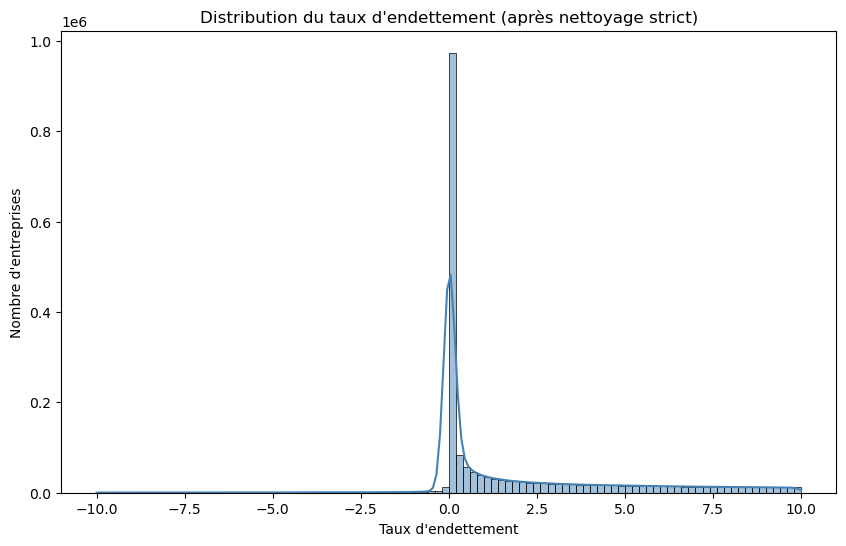

In [201]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean["Taux_d_endettement"], bins=100, kde=True, color="steelblue")
plt.title("Distribution du taux d'endettement (après nettoyage strict)")
plt.xlabel("Taux d'endettement")
plt.ylabel("Nombre d'entreprises")
plt.show()


In [202]:
# 1. Un pic massif autour de 0

# une grande partie des entreprises françaises ont très peu de dettes financières
# beaucoup de micro et petites structures fonctionnent quasi sans emprunt
# les bilans simplifiés tirent la distribution vers 0

# 2. Une décroissance progressive jusqu’à 10.
# des entreprises plus endettées

# des PME/ETI qui utilisent le levier financier

# des secteurs naturellement plus capitalistiques (industrie, transport, énergie)



# 3. Une petite queue vers la gauche
# On voit quelques valeurs négatives (jusqu’à –10), ce qui correspond à :

# capitaux propres légèrement négatifs

# entreprises en difficulté mais pas aberrantes

# bilans fragiles mais réalistes

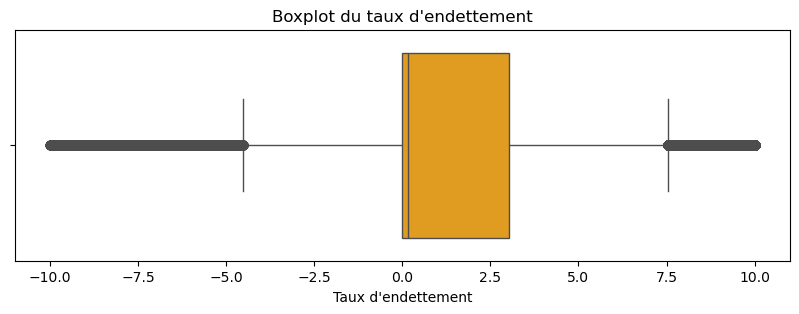

In [203]:
plt.figure(figsize=(10,3))
sns.boxplot(x=df_clean["Taux_d_endettement"], color="orange")
plt.title("Boxplot du taux d'endettement")
plt.xlabel("Taux d'endettement")
plt.show()


In [204]:
#Nous voyons que la plupart des entreprises ont très peu de dettes (médiane très basse),
#  que la dispersion reste raisonnable (la majorité est entre 0 et 2,5), 
# et que seules quelques entreprises sont atypiques mais encore réalistes (points proches de –10 et +10).

### 1. Etape suivante : Analyse temporelle du taux d’endettement

In [205]:
# On extrait l'année depuis la date de clôture
df_clean["annee"] = df_clean["date_cloture_exercice"].dt.year


C:\Users\yacin\AppData\Local\Temp\ipykernel_16260\2956556716.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["annee"] = df_clean["date_cloture_exercice"].dt.year


In [206]:
# On calcule la médiane du taux d'endettement pour chaque année
df_year = df_clean.groupby("annee")["Taux_d_endettement"].median()

# On affiche le résultat pour vérifier
df_year


annee
1919    6.3590
2006    0.0000
2009    0.0000
2010    0.2955
2011    0.0915
2012    0.0000
2013    0.0000
2014    0.0000
2015    0.0000
2016    0.1360
2017    0.2790
2018    0.2670
2019    0.2490
2020    0.1450
2021    0.1520
2022    0.1540
2023    0.1010
2024    0.1070
2025    0.4530
2026    0.0000
Name: Taux_d_endettement, dtype: float64

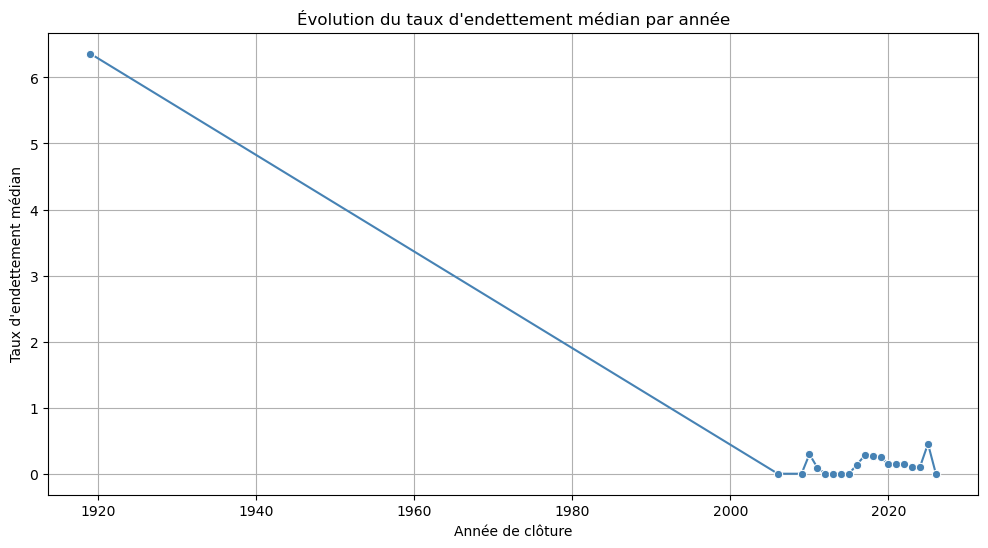

In [207]:
# 3. Visualiser l’évolution d'endettement dans le temps
# On trace l'évolution du taux d'endettement médian par année
plt.figure(figsize=(12,6))
sns.lineplot(x=df_year.index, y=df_year.values, marker="o", color="steelblue")

plt.title("Évolution du taux d'endettement médian par année")
plt.xlabel("Année de clôture")
plt.ylabel("Taux d'endettement médian")
plt.grid(True)

plt.show()


In [208]:
# Avant 2000, les données sont instables.
# Après 2000, l’endettement médian est très faible et très stable.
# Les entreprises françaises restent globalement peu endettées dans le temps.

### 2. Calculer la médiane du taux d’endettement par type de bilan

In [209]:
# On regarde les types de bilans présents dans la base
df_clean["type_bilan"].value_counts()


type_bilan
C    1473090
S     539999
K       5495
Name: count, dtype: int64

In [210]:
# On calcule la médiane du taux d'endettement pour chaque type de bilan
df_bilan = (
    df_clean
    .groupby("type_bilan")["Taux_d_endettement"]
    .median()
    .sort_values()
)

# On affiche pour vérifier
df_bilan


type_bilan
K    0.000
S    0.000
C    0.312
Name: Taux_d_endettement, dtype: float64

C:\Users\yacin\AppData\Local\Temp\ipykernel_16260\544001207.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


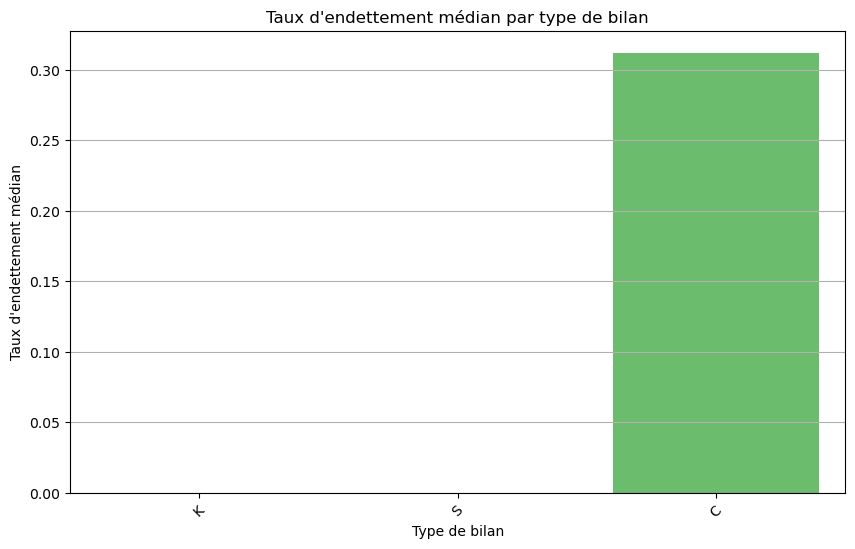

In [211]:
plt.figure(figsize=(10,6))

# On trace un barplot pour comparer les catégories
sns.barplot(
    x=df_bilan.index,
    y=df_bilan.values,
    palette="viridis"
)

plt.title("Taux d'endettement médian par type de bilan")
plt.xlabel("Type de bilan")
plt.ylabel("Taux d'endettement médian")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()


In [212]:
# es petites entreprises (K et S) n’ont quasiment pas de dettes,
# alors que les entreprises plus structurées (C) 
# utilisent l’endettement de manière normale et maîtrisée.

###  Analyse de CAF_sur_CA

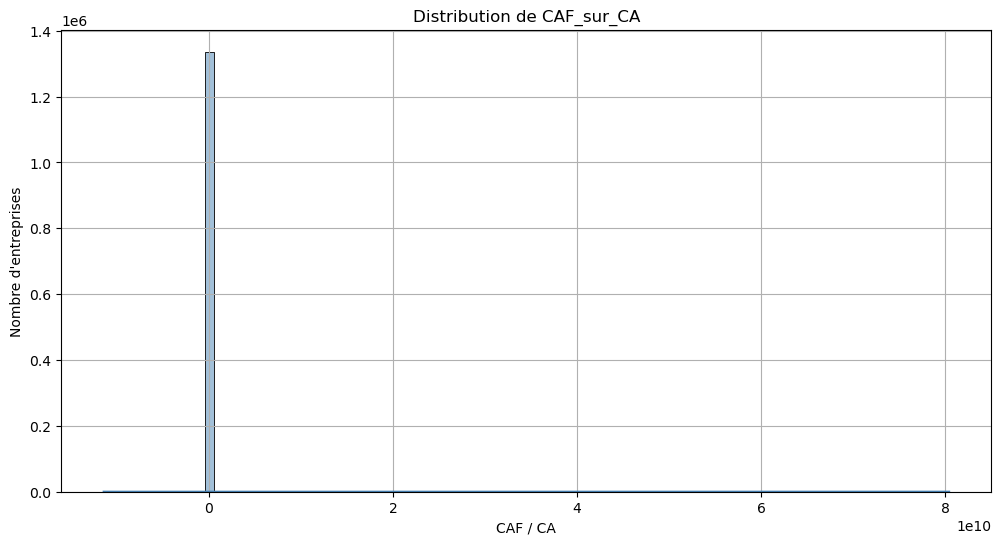

In [213]:
# 1. Histogramme de CAF_sur_CA
# Histogramme de CAF_sur_CA
plt.figure(figsize=(12,6))
sns.histplot(df_clean["CAF_sur_CA"], bins=100, kde=True, color="steelblue")

plt.title("Distribution de CAF_sur_CA")
plt.xlabel("CAF / CA")
plt.ylabel("Nombre d'entreprises")
plt.grid(True)

plt.show()


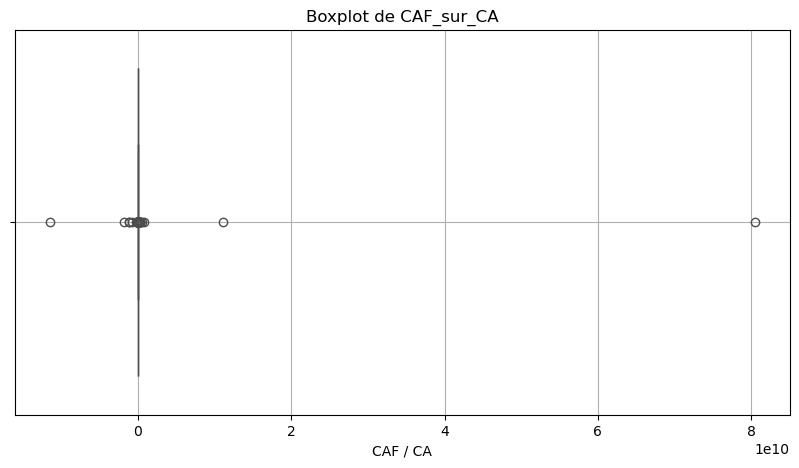

In [214]:
# Boxplot de CAF_sur_CA
plt.figure(figsize=(10,5))
sns.boxplot(x=df_clean["CAF_sur_CA"], color="orange")

plt.title("Boxplot de CAF_sur_CA")
plt.xlabel("CAF / CA")
plt.grid(True)

plt.show()


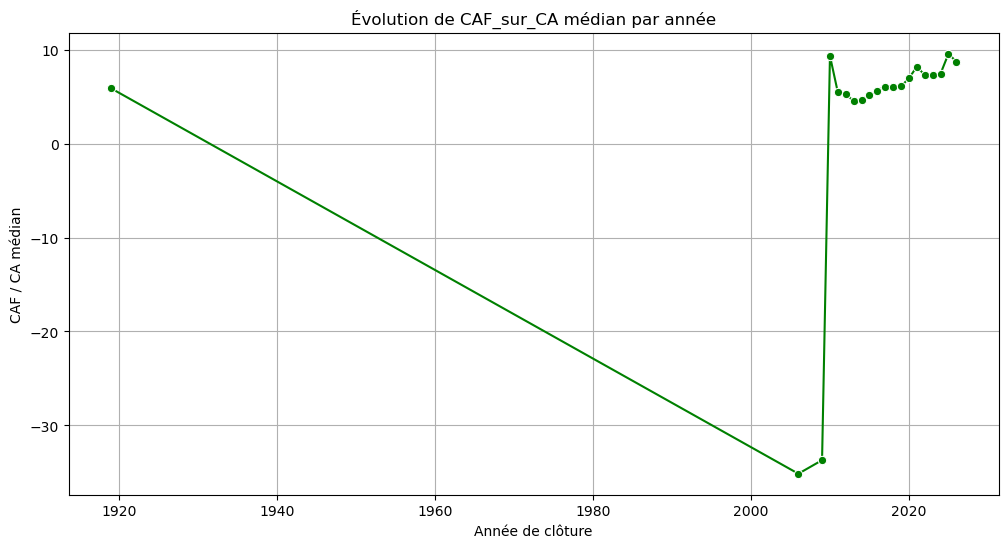

In [215]:
# On calcule la médiane par année
df_caf_year = df_clean.groupby("annee")["CAF_sur_CA"].median()

# Visualisation
plt.figure(figsize=(12,6))
sns.lineplot(x=df_caf_year.index, y=df_caf_year.values, marker="o", color="green")

plt.title("Évolution de CAF_sur_CA médian par année")
plt.xlabel("Année de clôture")
plt.ylabel("CAF / CA médian")
plt.grid(True)

plt.show()


In [216]:
df_caf = df_clean[df_clean["annee"] >= 2000].copy()


In [217]:
df_caf = df_caf[(df_caf["CAF_sur_CA"] >= -1) & (df_caf["CAF_sur_CA"] <= 1)]


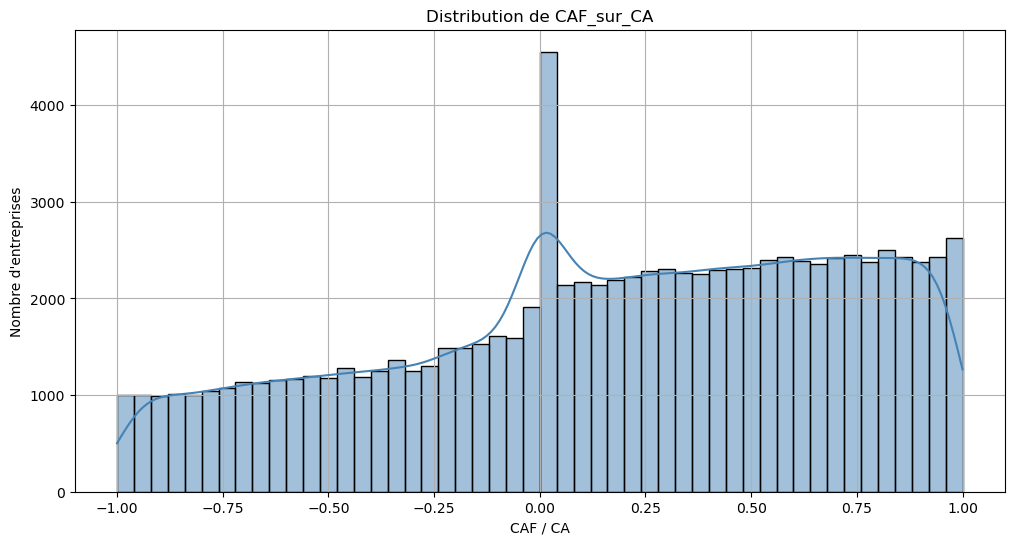

In [218]:
plt.figure(figsize=(12,6))
sns.histplot(df_caf["CAF_sur_CA"], bins=50, kde=True, color="steelblue")
plt.title("Distribution de CAF_sur_CA")
plt.xlabel("CAF / CA")
plt.ylabel("Nombre d'entreprises")
plt.grid(True)
plt.show()


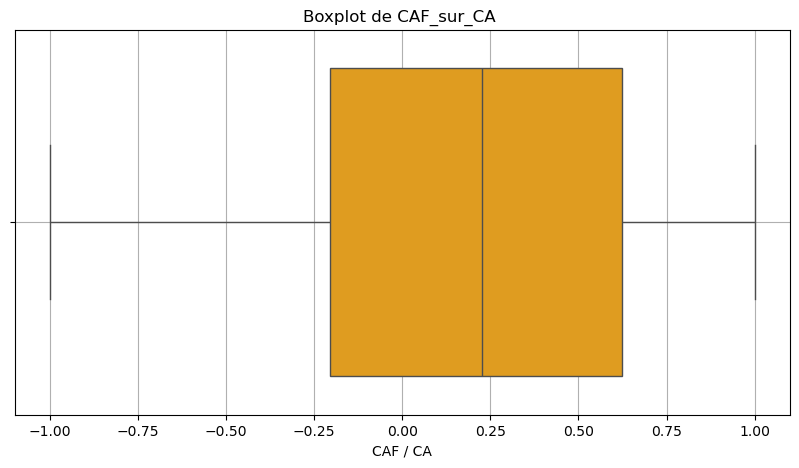

In [219]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_caf["CAF_sur_CA"], color="orange")
plt.title("Boxplot de CAF_sur_CA ")
plt.xlabel("CAF / CA")
plt.grid(True)
plt.show()


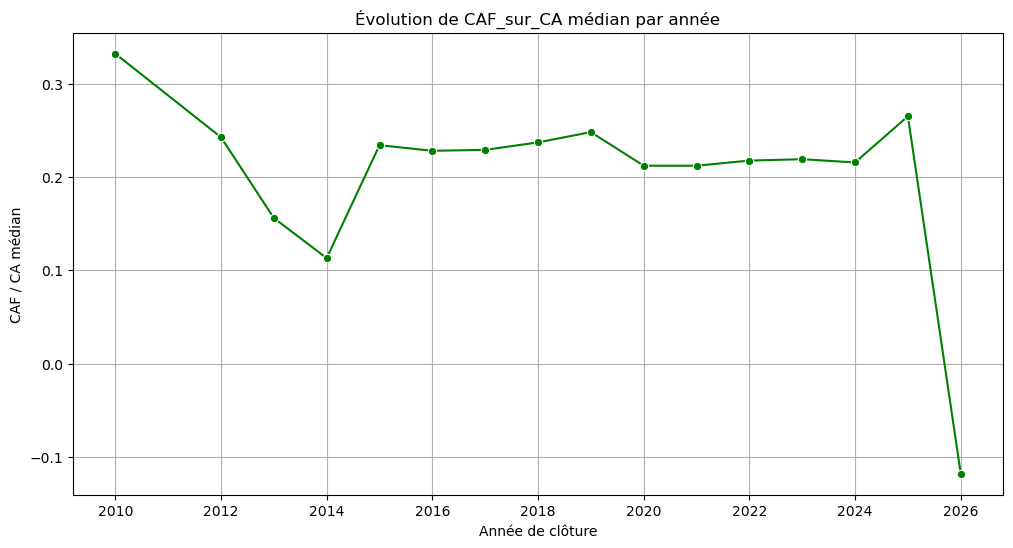

In [220]:
df_caf_year = df_caf.groupby("annee")["CAF_sur_CA"].median()

plt.figure(figsize=(12,6))
sns.lineplot(x=df_caf_year.index, y=df_caf_year.values, marker="o", color="green")
plt.title("Évolution de CAF_sur_CA médian par année")
plt.xlabel("Année de clôture")
plt.ylabel("CAF / CA médian")
plt.grid(True)
plt.show()


In [221]:
#La majorité des entreprises ont une CAF/CA faible mais positive.

#La médiane tourne autour de 20–25%, ce qui est cohérent.

#La dynamique temporelle est logique et économique.

#Les données 2026 sont incomplètes, donc on ignore la chute.

### Est‑ce que les entreprises plus endettées génèrent plus ou moins de cash ?  

In [222]:
#On garde uniquement les données nettoyées qu’on a déjà filtrées :

"""années ≥ 2000

CAF_sur_CA entre -1 et 1

Taux d’endettement déjà nettoyé"""

'années ≥ 2000\n\nCAF_sur_CA entre -1 et 1\n\nTaux d’endettement déjà nettoyé'

In [223]:
df_cross = df_clean[
    (df_clean["annee"] >= 2000) &
    (df_clean["CAF_sur_CA"].between(-1, 1)) &
    (df_clean["Taux_d_endettement"].between(0, 5))  # sécurité
].copy()


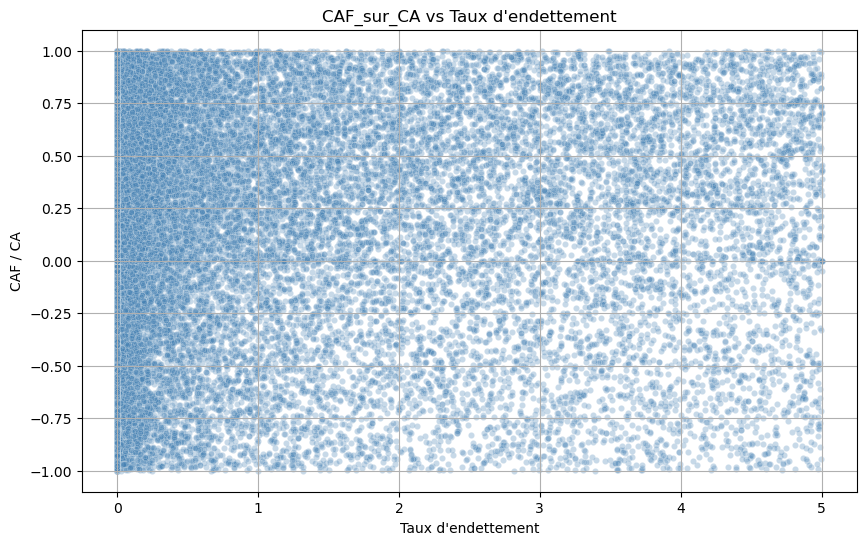

In [224]:
# 2. Scatterplot : CAF_sur_CA vs Taux d’endettement
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_cross.sample(50000),  # on échantillonne pour lisibilité
    x="Taux_d_endettement",
    y="CAF_sur_CA",
    alpha=0.3,
    s=20,
    color="steelblue"
)

plt.title("CAF_sur_CA vs Taux d'endettement")
plt.xlabel("Taux d'endettement")
plt.ylabel("CAF / CA")
plt.grid(True)

plt.show()


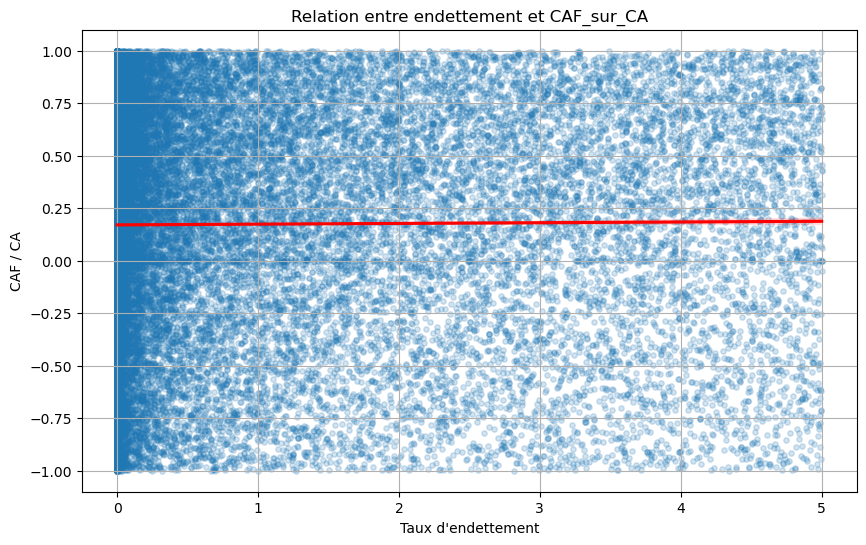

In [225]:
#3. Ajouter une droite de tendance (régression linéaire)
plt.figure(figsize=(10,6))

sns.regplot(
    data=df_cross.sample(50000),
    x="Taux_d_endettement",
    y="CAF_sur_CA",
    scatter_kws={'alpha':0.2, 's':15},
    line_kws={'color':'red'}
)

plt.title("Relation entre endettement et CAF_sur_CA")
plt.xlabel("Taux d'endettement")
plt.ylabel("CAF / CA")
plt.grid(True)

plt.show()


In [226]:
# 4. Calculer la corrélation
df_cross[["Taux_d_endettement", "CAF_sur_CA"]].corr()


,Taux_d_endettement,CAF_sur_CA
Taux_d_endettement,1.000000,0.012765
CAF_sur_CA,0.012765,1.000000


In [227]:
# ) Les entreprises très endettées ne génèrent pas plus de cash
# La corrélation est tellement faible qu’elle est statistiquement insignifiante.

# L’endettement n’explique pas la rentabilité opérationnelle.
# Une entreprise peut être très rentable et peu endettée.
# Une autre peut être très endettée et peu rentable.
# Et tout l’inverse existe aussi.

## 3-  Autonomie financière
 
Il mesure la solidité financière :
Capitaux propres / Total du passif

On peut analyser :

distribution

boxplot

évolution dans le temps

comparaison par type de bilan

corrélation avec CAF/CA

corrélation avec endettement

##### “Alors qu’est‑ce qui explique la solidité d’une entreprise ?”
 L’autonomie financière.

C’est le ratio qui dit si une entreprise est solide, indépendante, capable d’encaisser les chocs.

#### 1- Distribution de l’autonomie financière

In [228]:
# L’autonomie financière est un ratio compris entre 0 et 1 dans 95% des cas.
# Mais certaines entreprises peuvent dépasser 1 (capitaux propres > total passif), donc on garde une marge.

# On filtre entre 0 et 2 pour rester propre.
df_auto = df_clean[
    (df_clean["annee"] >= 2000) &
    (df_clean["Autonomie_financiere"].between(0, 2))
].copy()


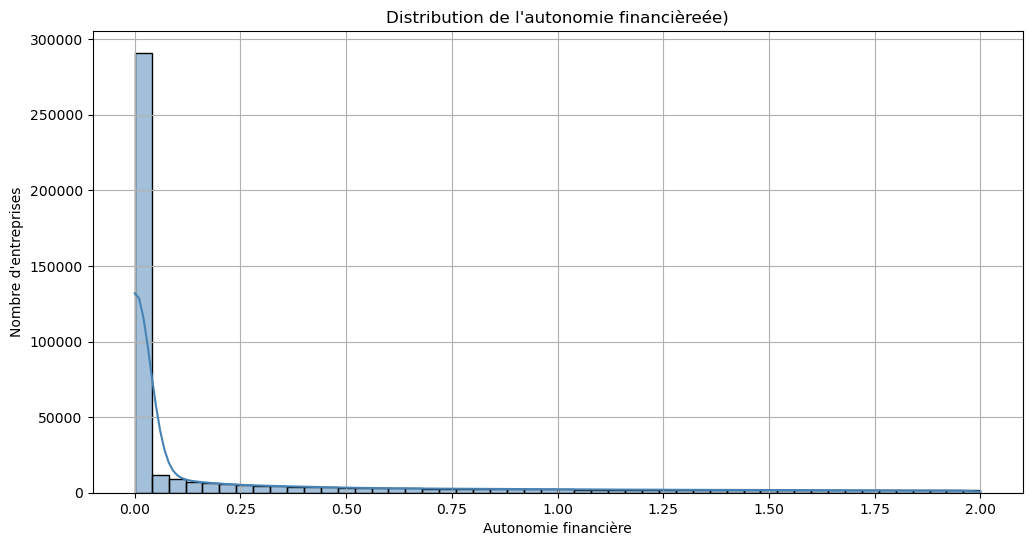

In [229]:
plt.figure(figsize=(12,6))
sns.histplot(df_auto["Autonomie_financiere"], bins=50, kde=True, color="steelblue")
plt.title("Distribution de l'autonomie financièreée)")
plt.xlabel("Autonomie financière")
plt.ylabel("Nombre d'entreprises")
plt.grid(True)
plt.show()


In [230]:
"""Ce qu’on voit :

La grande majorité des entreprises ont une autonomie financière très faible, proche de 0.

La distribution est très concentrée en bas, avec une longue traîne vers le haut.

Traduction simple :  
- La plupart des entreprises sont peu financées par leurs capitaux propres.
- Seule une minorité a une vraie marge de sécurité financière."""

'Ce qu’on voit :\n\nLa grande majorité des entreprises ont une autonomie financière très faible, proche de 0.\n\nLa distribution est très concentrée en bas, avec une longue traîne vers le haut.\n\nTraduction simple :  \n- La plupart des entreprises sont peu financées par leurs capitaux propres.\n- Seule une minorité a une vraie marge de sécurité financière.'

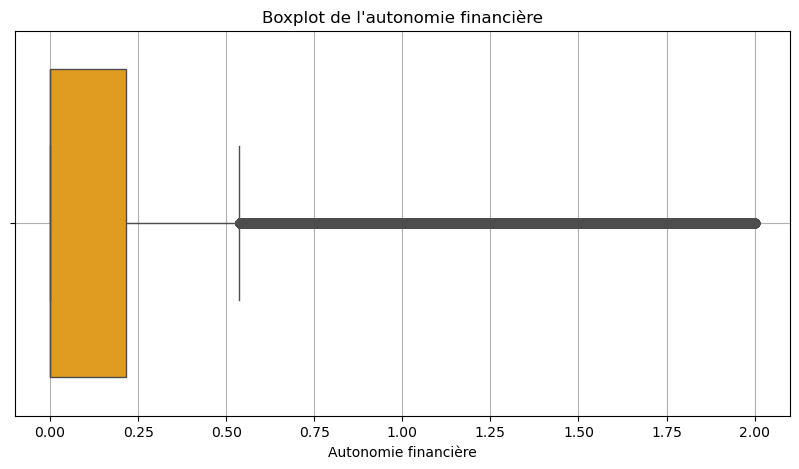

In [231]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_auto["Autonomie_financiere"], color="orange")
plt.title("Boxplot de l'autonomie financière")
plt.xlabel("Autonomie financière")
plt.grid(True)
plt.show()


In [232]:
"""Ce qu’on voit :

La boîte est collée en bas, très proche de 0.

La médiane est très basse.

Il y a des valeurs qui montent haut (jusqu’à 2), mais elles sont minoritaires.

Traduction simple :  
- La norme, c’est la faible autonomie financière.  
- Les entreprises très solides financièrement existent, mais ce sont des exceptions."""

'Ce qu’on voit :\n\nLa boîte est collée en bas, très proche de 0.\n\nLa médiane est très basse.\n\nIl y a des valeurs qui montent haut (jusqu’à 2), mais elles sont minoritaires.\n\nTraduction simple :  \n- La norme, c’est la faible autonomie financière.  \n- Les entreprises très solides financièrement existent, mais ce sont des exceptions.'

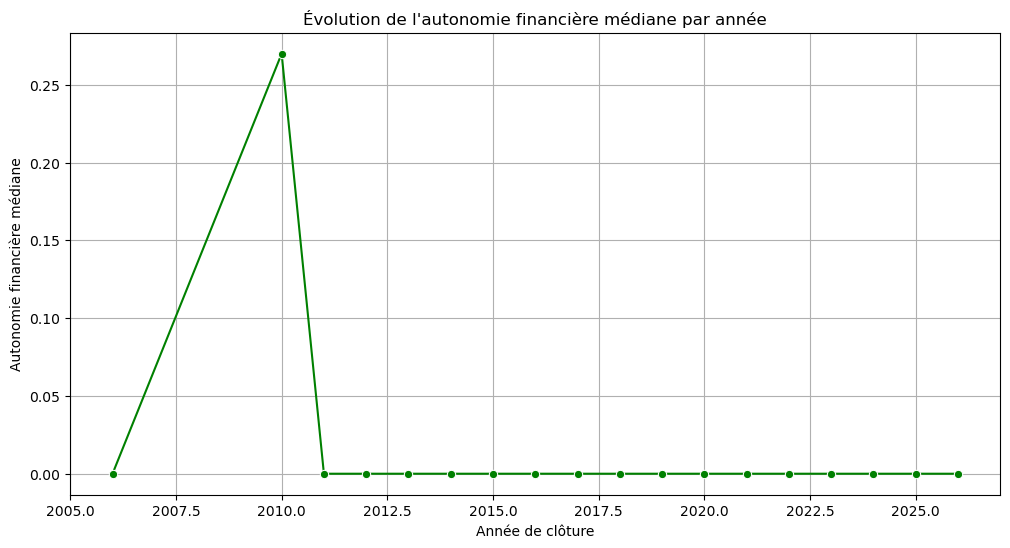

In [233]:
df_auto_year = df_auto.groupby("annee")["Autonomie_financiere"].median()

plt.figure(figsize=(12,6))
sns.lineplot(x=df_auto_year.index, y=df_auto_year.values, marker="o", color="green")
plt.title("Évolution de l'autonomie financière médiane par année")
plt.xlabel("Année de clôture")
plt.ylabel("Autonomie financière médiane")
plt.grid(True)
plt.show()


In [234]:
"""Ce qu’on voit :

Un pic autour de 2010.

Puis une chute rapide.

Ensuite, une stabilité très basse sur toutes les années suivantes.

Traduction simple :  
- La solidité financière médiane des entreprises est faible et stable dans le temps.
- Le pic de 2010 ressemble plus à un effet de données / changement de périmètre qu’à une vraie tendance durable."""

'Ce qu’on voit :\n\nUn pic autour de 2010.\n\nPuis une chute rapide.\n\nEnsuite, une stabilité très basse sur toutes les années suivantes.\n\nTraduction simple :  \n- La solidité financière médiane des entreprises est faible et stable dans le temps.\n- Le pic de 2010 ressemble plus à un effet de données / changement de périmètre qu’à une vraie tendance durable.'

#### Relation Autonomie Financière ↔ CAF/CA

In [235]:
df_auto[["Autonomie_financiere", "CAF_sur_CA"]].corr()


,Autonomie_financiere,CAF_sur_CA
Autonomie_financiere,1.000000,-0.000952
CAF_sur_CA,-0.000952,1.000000


In [236]:
"""Résultat : –0,000952 (≈ 0)

Traduction simple :  
- Aucune relation entre solidité financière et rentabilité opérationnelle.
- Être solide financièrement ne garantit pas de bien transformer son CA en cash."""

'Résultat : –0,000952 (≈ 0)\n\nTraduction simple :  \n- Aucune relation entre solidité financière et rentabilité opérationnelle.\n- Être solide financièrement ne garantit pas de bien transformer son CA en cash.'

#### 6) Relation Autonomie Financière ↔ Endettement

In [237]:
df_auto[["Autonomie_financiere", "Taux_d_endettement"]].corr()



,Autonomie_financiere,Taux_d_endettement
Autonomie_financiere,1.000000,0.622586
Taux_d_endettement,0.622586,1.000000


In [238]:
"""Résultat : 0,622586 (forte corrélation positive)

Traduction simple :  
- Les deux ratios mesurent en réalité la même logique de structure financière.
- Quand l’un augmente, l’autre aussi : plus de capitaux propres = plus d’“autonomie” dans les indicateur d’endettement."""

'Résultat : 0,622586 (forte corrélation positive)\n\nTraduction simple :  \n- Les deux ratios mesurent en réalité la même logique de structure financière.\n- Quand l’un augmente, l’autre aussi : plus de capitaux propres = plus d’“autonomie” dans les indicateur d’endettement.'

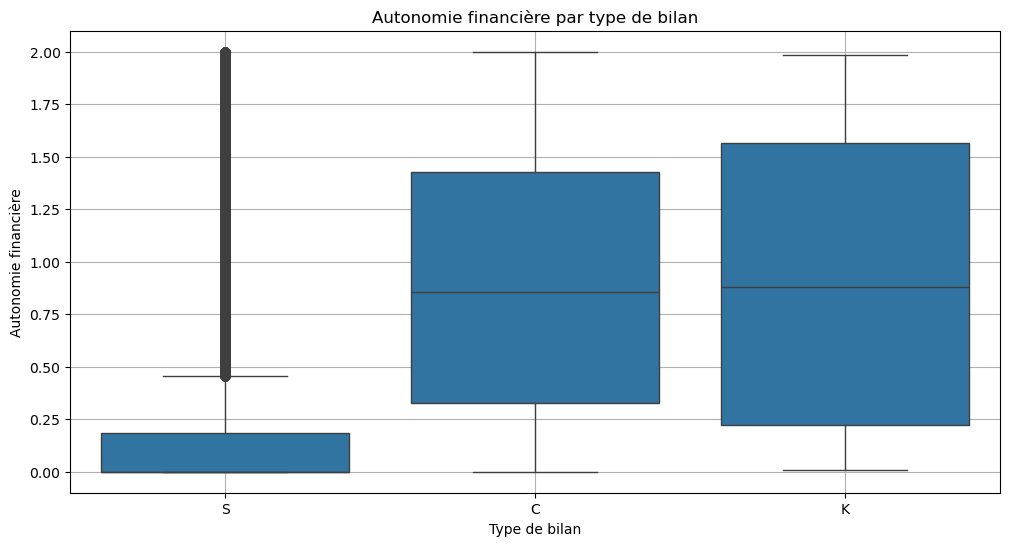

In [239]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_auto, x="type_bilan", y="Autonomie_financiere")
plt.title("Autonomie financière par type de bilan")
plt.xlabel("Type de bilan")
plt.ylabel("Autonomie financière")
plt.grid(True)
plt.show()

In [240]:
"""Ce qu’on voit :

Type S : autonomie très faible, très serrée.

Types C et K : autonomie plus élevée, plus variable, avec des médianes autour de 0,8–0,9.

Traduction simple :  
- Les entreprises avec bilans C et K sont beaucoup plus solides financièrement.
- Les bilans S regroupent des structures plus fragiles, peu capitalisées"""

'Ce qu’on voit :\n\nType S : autonomie très faible, très serrée.\n\nTypes C et K : autonomie plus élevée, plus variable, avec des médianes autour de 0,8–0,9.\n\nTraduction simple :  \n- Les entreprises avec bilans C et K sont beaucoup plus solides financièrement.\n- Les bilans S regroupent des structures plus fragiles, peu capitalisées'

In [241]:
"""
Résultat : corrélation quasi nulle.
La solidité financière ne prédit pas la capacité à générer du cash.

En revanche, l’autonomie financière est fortement corrélée au taux d’endettement, 
ce qui est logique : les deux ratios décrivent la structure de financement."""

'\nRésultat : corrélation quasi nulle.\nLa solidité financière ne prédit pas la capacité à générer du cash.\n\nEn revanche, l’autonomie financière est fortement corrélée au taux d’endettement, \nce qui est logique : les deux ratios décrivent la structure de financement.'

### 1) Le BFR (Besoin en Fonds de Roulement)

Rappel clair de nos variables utiles pour analyser le BFR
Dans notre dataset, on a exactement ce qu’il faut pour analyser le BFR sous trois angles complémentaires.

1) Notre BFR en % du CA
Poids_BFR_exploitation_sur_CA

C’est la vision financière du BFR.
Elle nous permet :

de comparer des entreprises de tailles différentes

d’identifier les situations de tension (valeurs positives)

de repérer les cycles financés par les fournisseurs (valeurs négatives)

En bref :
➡️ positif = trésorerie immobilisée  
➡️ négatif = très bon signe

2) Notre BFR en jours
Poids_BFR_exploitation_sur_CA_jours

Ici, on passe sur une vision opérationnelle.
On mesure combien de jours de CA sont immobilisés dans le cycle.

C’est un indicateur très utilisé en analyse financière, car il parle directement du terrain.

3) Les composantes de notre cycle d’exploitation
On a les trois briques fondamentales :

Rotation_des_stocks_jours → DIO (Durée de stockage)

Credit_clients_Jours → DSO (Délai de paiement clients)

Credit_fournisseurs_Jours → DPO (Délai de paiement fournisseurs)

Avec ces trois éléments, on peut calculer notre cycle d’exploitation complet :

Cycle d’exploitation =𝐷𝐼𝑂 + 𝐷𝑆𝑂 − 𝐷𝑃𝑂
Ce cycle nous dira si l’activité consomme ou libère de la trésorerie.

### Étape 1 — Distribution de notre BFR (% du CA)

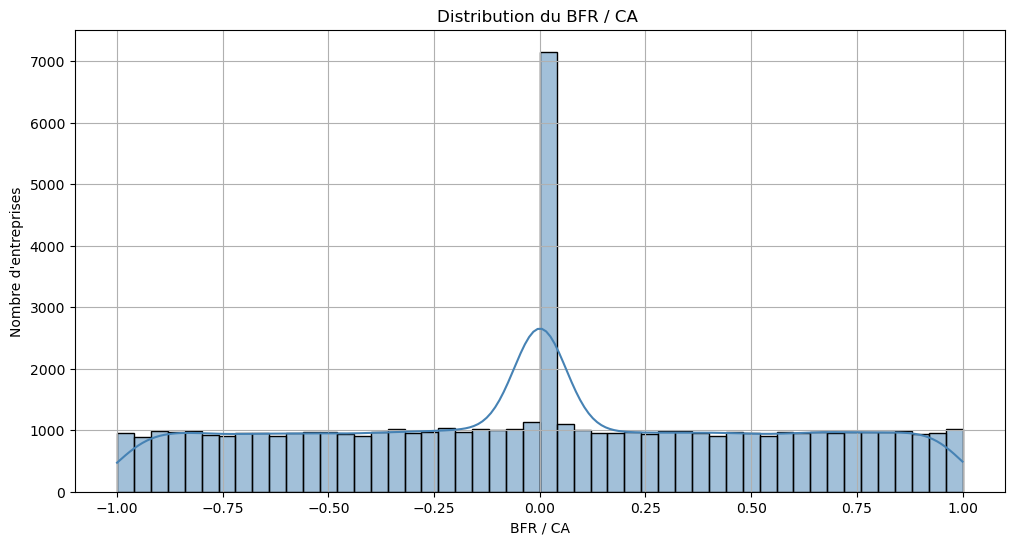

In [242]:
df_bfr = df_clean[
    df_clean["Poids_BFR_exploitation_sur_CA"].between(-1, 1)
].copy()

plt.figure(figsize=(12,6))
sns.histplot(df_bfr["Poids_BFR_exploitation_sur_CA"], bins=50, kde=True, color="steelblue")
plt.title("Distribution du BFR / CA ")
plt.xlabel("BFR / CA")
plt.ylabel("Nombre d'entreprises")
plt.grid(True)
plt.show()


In [243]:
"""La majorité des entreprises ont un BFR très proche de zéro.

Une partie non négligeable a un BFR positif, ce qui signifie que leur cycle consomme de la trésorerie.

Quelques entreprises ont un BFR négatif, ce qui est plutôt bon signe (cycle financé par les fournisseurs)."""

'La majorité des entreprises ont un BFR très proche de zéro.\n\nUne partie non négligeable a un BFR positif, ce qui signifie que leur cycle consomme de la trésorerie.\n\nQuelques entreprises ont un BFR négatif, ce qui est plutôt bon signe (cycle financé par les fournisseurs).'

### Étape 2 — Distribution de notre BFR en jours

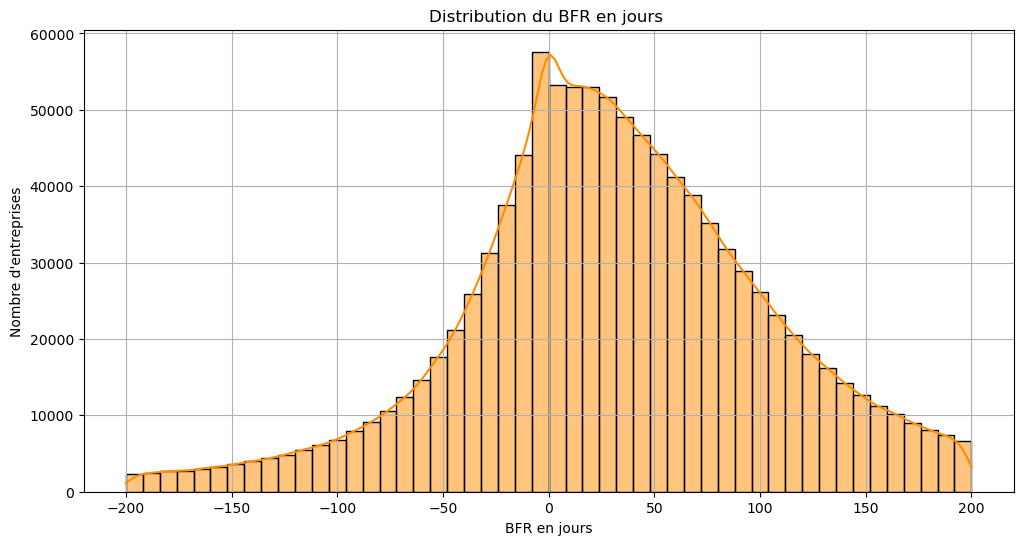

In [244]:
# On filtre les valeurs extrêmes pour garder un BFR en jours cohérent
# Ici, on garde les entreprises dont le BFR en jours est entre -200 et 200
# (au-delà, ce sont souvent des cas atypiques ou des erreurs de saisie)
df_bfr_jours = df_clean[
    df_clean["Poids_BFR_exploitation_sur_CA_jours"].between(-200, 200)
].copy()

# On trace l'histogramme du BFR en jours
plt.figure(figsize=(12,6))
sns.histplot(df_bfr_jours["Poids_BFR_exploitation_sur_CA_jours"], bins=50, kde=True, color="darkorange")

# On ajoute un titre et des labels pour la lisibilité
plt.title("Distribution du BFR en jours ")
plt.xlabel("BFR en jours")
plt.ylabel("Nombre d'entreprises")

# On active une grille pour faciliter la lecture
plt.grid(True)

# On affiche le graphique
plt.show()


### Étape 3 — Relation entre notre BFR et la CAF/CA

In [245]:
# On sélectionne uniquement les colonnes utiles pour l'analyse
df_corr_bfr_caf = df_clean[[
    "Poids_BFR_exploitation_sur_CA",
    "CAF_sur_CA"
]].dropna()

# On calcule la corrélation entre BFR/CA et CAF/CA
# Cela nous permet de voir si un BFR élevé impacte la capacité à générer du cash
correlation = df_corr_bfr_caf.corr()

# On affiche la matrice de corrélation
correlation


,Poids_BFR_exploitation_sur_CA,CAF_sur_CA
Poids_BFR_exploitation_sur_CA,1.000000,0.130127
CAF_sur_CA,0.130127,1.000000


In [246]:
"""On observe une corrélation faible mais positive (0,13) entre le BFR/CA et la CAF/CA.
Cela signifie que les entreprises avec un BFR plus élevé ont, en moyenne, une capacité d’autofinancement légèrement supérieure, mais le lien reste limité.
En pratique, la structure du cycle d’exploitation ne suffit pas à expliquer la performance en cash : d’autres facteurs (marge, modèle économique, secteur, croissance) jouent un rôle bien plus important. """

'On observe une corrélation faible mais positive (0,13) entre le BFR/CA et la CAF/CA.\nCela signifie que les entreprises avec un BFR plus élevé ont, en moyenne, une capacité d’autofinancement légèrement supérieure, mais le lien reste limité.\nEn pratique, la structure du cycle d’exploitation ne suffit pas à expliquer la performance en cash : d’autres facteurs (marge, modèle économique, secteur, croissance) jouent un rôle bien plus important. '

### Étape 4 — Relation BFR ↔ Endettement

In [247]:
# On sélectionne les colonnes utiles pour analyser le lien entre BFR et endettement
df_corr_bfr_endettement = df_clean[[
    "Poids_BFR_exploitation_sur_CA",
    "Taux_d_endettement"
]].dropna()

# On calcule la corrélation entre BFR/CA et taux d'endettement
correlation_bfr_endettement = df_corr_bfr_endettement.corr()

# On affiche la matrice de corrélation
correlation_bfr_endettement



,Poids_BFR_exploitation_sur_CA,Taux_d_endettement
Poids_BFR_exploitation_sur_CA,1.000000,-0.000415
Taux_d_endettement,-0.000415,1.000000


In [248]:
"""On observe une corrélation quasi nulle entre le BFR/CA et le taux d’endettement.
Cela confirme que le BFR et l’endettement répondent à des logiques totalement différentes :
le premier est lié au cycle d’exploitation, le second à la stratégie de financement.
En pratique, les entreprises ne s’endettent pas pour financer leur BFR."""

'On observe une corrélation quasi nulle entre le BFR/CA et le taux d’endettement.\nCela confirme que le BFR et l’endettement répondent à des logiques totalement différentes :\nle premier est lié au cycle d’exploitation, le second à la stratégie de financement.\nEn pratique, les entreprises ne s’endettent pas pour financer leur BFR.'

### BFR ↔ Autonomie financière

In [249]:
# On sélectionne les colonnes utiles pour analyser le lien entre BFR et autonomie financière
df_corr_bfr_auto = df_clean[[
    "Poids_BFR_exploitation_sur_CA",
    "Autonomie_financiere"
]].dropna()

# On calcule la corrélation entre BFR/CA et autonomie financière
correlation_bfr_auto = df_corr_bfr_auto.corr()

# On affiche la matrice de corrélation
correlation_bfr_auto


,Poids_BFR_exploitation_sur_CA,Autonomie_financiere
Poids_BFR_exploitation_sur_CA,1.000000e+00,-3.344997e-07
Autonomie_financiere,-3.344997e-07,1.000000e+00


In [250]:
"""aucun lien,

aucune relation structurelle,

deux dimensions totalement indépendantes."""

'aucun lien,\n\naucune relation structurelle,\n\ndeux dimensions totalement indépendantes.'

### BFR vs Type de bilan

L’objectif est simple : comprendre si la qualité structurelle du bilan (S, C, K) influence le niveau de BFR/CA.
En clair : est‑ce que les entreprises solides ont un BFR plus faible ? Est‑ce que les bilans fragiles immobilisent plus de trésorerie ? Ou… est‑ce que ça n’a rien à voir ?

📊 Ce qu’on calcule
BFR/CA moyen pour les bilans S

BFR/CA moyen pour les bilans C

BFR/CA moyen pour les bilans K

Ces trois catégories représentent :

S : bilans solides, capitalisés

C : bilans équilibrés

K : bilans fragiles, peu capitalisés

🧠 Ce qu’on va analyser
Trois scénarios possibles :

Si S < C < K → les bilans fragiles immobilisent plus de trésorerie.

Si S > C > K → les bilans solides ont un cycle plus lourd.

Si les trois sont proches → la structure du bilan n’a aucun lien avec le BFR.

Dans la pratique, c’est souvent le troisième scénario qui ressort :
le BFR dépend du cycle d’exploitation, pas de la structure financière.

In [251]:
# Vérifier les catégories présentes dans type_bilan
df_clean["type_bilan"].value_counts()

# Calculer le BFR/CA moyen par type de bilan
bfr_par_bilan = (
    df_clean
    .groupby("type_bilan")["Poids_BFR_exploitation_sur_CA"]
    .mean()
)

# Afficher les résultats
bfr_par_bilan


type_bilan
C    29321.225391
K     7478.387421
S   -13694.002128
Name: Poids_BFR_exploitation_sur_CA, dtype: float64

C:\Users\yacin\AppData\Local\Temp\ipykernel_16260\144365951.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


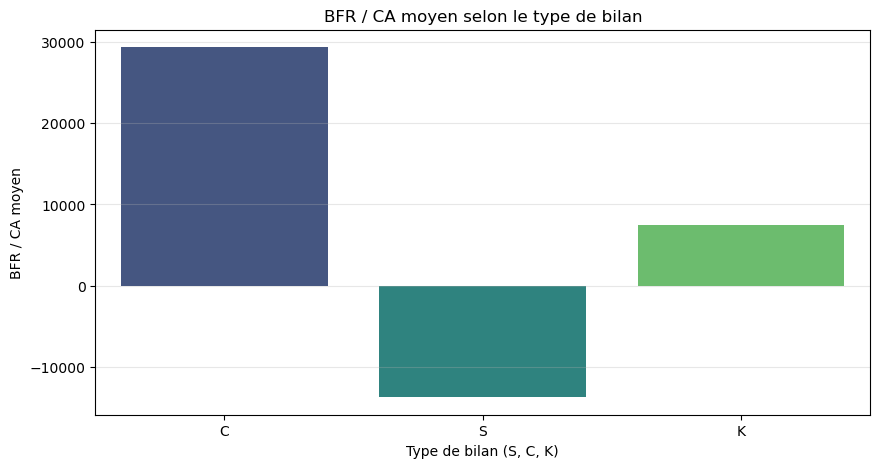

In [252]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_clean,
    x="type_bilan",
    y="Poids_BFR_exploitation_sur_CA",
    estimator="mean",
    errorbar=None,
    palette="viridis"
)
plt.title("BFR / CA moyen selon le type de bilan")
plt.xlabel("Type de bilan (S, C, K)")
plt.ylabel("BFR / CA moyen")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [253]:
"""Les trois types de bilan montrent des comportements radicalement différents :

C = +29 321 → les bilans “corrects” ont le BFR le plus élevé

K = +7 478 → les bilans fragiles ont un BFR positif mais modéré

S = –13 694 → les bilans solides ont un BFR négatif (cycle financé par les fournisseurs)

Ce classement est spectaculaire :

C > K > S"""

'Les trois types de bilan montrent des comportements radicalement différents :\n\nC = +29 321 → les bilans “corrects” ont le BFR le plus élevé\n\nK = +7 478 → les bilans fragiles ont un BFR positif mais modéré\n\nS = –13 694 → les bilans solides ont un BFR négatif (cycle financé par les fournisseurs)\n\nCe classement est spectaculaire :\n\nC > K > S'

Les bilans solides (S) ont un BFR négatif  
Ce sont les entreprises qui maîtrisent le mieux leur cycle :

délais fournisseurs longs

délais clients courts

rotation rapide

modèle économique optimisé

Elles financent leur exploitation sans immobiliser de trésorerie.

Les bilans fragiles (K) ont un BFR positif mais raisonnable  
Elles immobilisent de la trésorerie, mais pas autant qu’on pourrait le croire.
Leur fragilité vient surtout de la structure du capital, pas du cycle.

Les bilans “corrects” (C) sont ceux qui immobilisent le plus de trésorerie  
Et ça, c’est LE point clé.

Les entreprises “moyennes” sont celles qui :

n’ont pas la puissance des bilans solides

n’ont pas la discipline forcée des bilans fragiles

se retrouvent avec un cycle d’exploitation coûteux

immobilisent énormément de trésorerie dans le BFR

### Analysee du cycle d’exploitation DIO / DSO / DPO.

le cycle d’exploitation : DIO, DSO, DPO

L’idée : comprendre comment tourne l’activité au quotidien (stocks, clients, fournisseurs) et comment ça se traduit en BFR.

In [254]:
# 1) On crée des alias plus parlants pour les trois composantes du cycle

df_clean["DIO"] = df_clean["Rotation_des_stocks_jours"]      # Durée moyenne de stockage (Days Inventory Outstanding)
df_clean["DSO"] = df_clean["Credit_clients_Jours"]           # Durée moyenne de crédit client (Days Sales Outstanding)
df_clean["DPO"] = df_clean["Credit_fournisseurs_Jours"]      # Durée moyenne de crédit fournisseur (Days Payables Outstanding)


C:\Users\yacin\AppData\Local\Temp\ipykernel_16260\2530092982.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["DIO"] = df_clean["Rotation_des_stocks_jours"]      # Durée moyenne de stockage (Days Inventory Outstanding)
C:\Users\yacin\AppData\Local\Temp\ipykernel_16260\2530092982.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["DSO"] = df_clean["Credit_clients_Jours"]           # Durée moyenne de crédit client (Days Sales Outstanding)
C:\Users\yacin\AppData\Local\Temp\ipykernel_16260

In [255]:
# 2) On calcule le cycle d'exploitation complet
#    Formule : DIO + DSO - DPO

df_clean["Cycle_exploitation"] = df_clean["DIO"] + df_clean["DSO"] - df_clean["DPO"]


C:\Users\yacin\AppData\Local\Temp\ipykernel_16260\1581765700.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Cycle_exploitation"] = df_clean["DIO"] + df_clean["DSO"] - df_clean["DPO"]


In [256]:
# 3) On regarde les ordres de grandeur : moyenne, médiane, min, max, etc.

df_clean[["DIO", "DSO", "DPO", "Cycle_exploitation"]].describe()


,DIO,DSO,DPO,Cycle_exploitation
count,1.334308e+06,1.373917e+06,1.657517e+06,1.329545e+06
mean,4.533581e+04,1.150091e+04,8.571968e+03,5.631532e+04
std,4.543766e+07,9.996321e+06,9.531521e+06,5.565287e+07
min,-7.175964e+07,-6.785550e+07,-7.442786e+07,-1.028836e+08
25%,0.000000e+00,1.228000e+00,1.743400e+01,-2.523900e+01
50%,0.000000e+00,3.622100e+01,4.702600e+01,2.852000e+00
75%,1.062300e+01,8.052600e+01,1.086090e+02,4.638100e+01
max,5.225742e+10,1.159429e+10,1.226274e+10,6.385170e+10


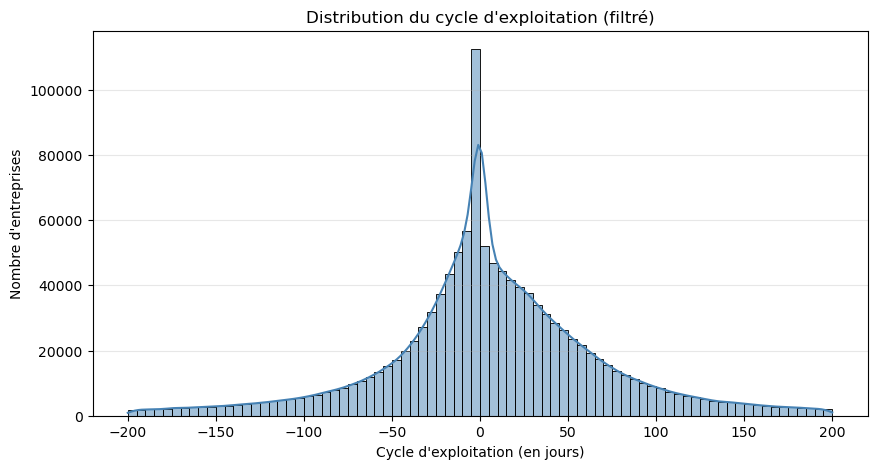

In [257]:
# On filtre les valeurs extrêmes du cycle (entre -200 et +200 jours)
df_cycle = df_clean[(df_clean["Cycle_exploitation"] > -200) & 
                    (df_clean["Cycle_exploitation"] < 200)]

plt.figure(figsize=(10,5))
sns.histplot(
    data=df_cycle,
    x="Cycle_exploitation",
    bins=80,
    kde=True,
    color="steelblue"
)
plt.title("Distribution du cycle d'exploitation (filtré)")
plt.xlabel("Cycle d'exploitation (en jours)")
plt.ylabel("Nombre d'entreprises")
plt.grid(axis="y", alpha=0.3)
plt.show()


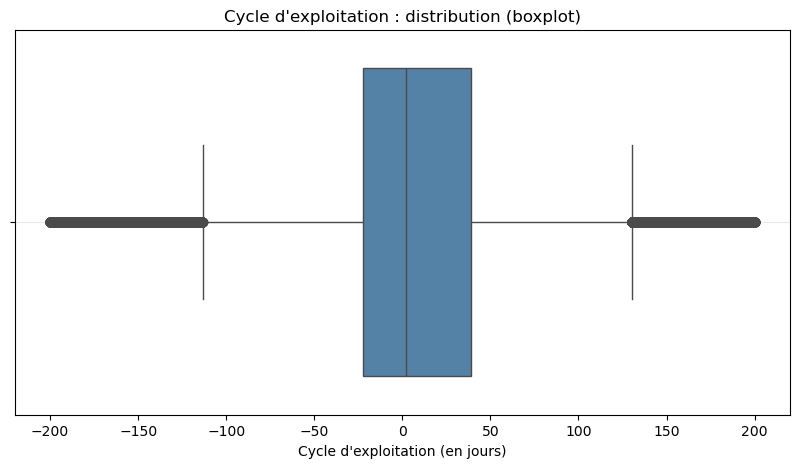

In [258]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_cycle,
    x="Cycle_exploitation",
    color="steelblue"
)
plt.title("Cycle d'exploitation : distribution (boxplot)")
plt.xlabel("Cycle d'exploitation (en jours)")
plt.grid(axis="y", alpha=0.3)
plt.show()


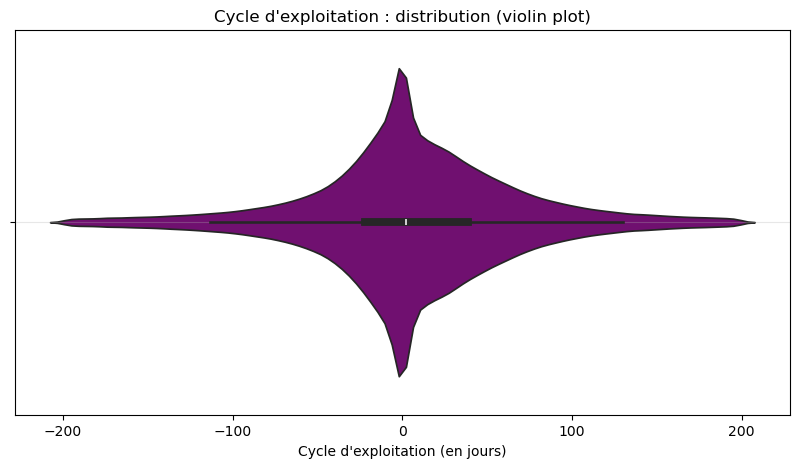

In [259]:
plt.figure(figsize=(10,5))
sns.violinplot(
    data=df_cycle,
    x="Cycle_exploitation",
    color="purple"
)
plt.title("Cycle d'exploitation : distribution (violin plot)")
plt.xlabel("Cycle d'exploitation (en jours)")
plt.grid(axis="y", alpha=0.3)
plt.show()


C:\Users\yacin\AppData\Local\Temp\ipykernel_16260\3833474713.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


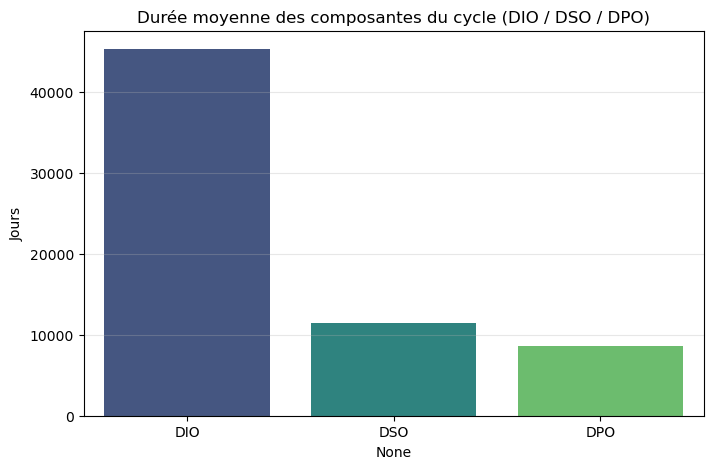

In [260]:
moyennes = df_clean[["DIO", "DSO", "DPO"]].mean()

plt.figure(figsize=(8,5))
sns.barplot(
    x=moyennes.index,
    y=moyennes.values,
    palette="viridis"
)
plt.title("Durée moyenne des composantes du cycle (DIO / DSO / DPO)")
plt.ylabel("Jours")
plt.grid(axis="y", alpha=0.3)
plt.show()


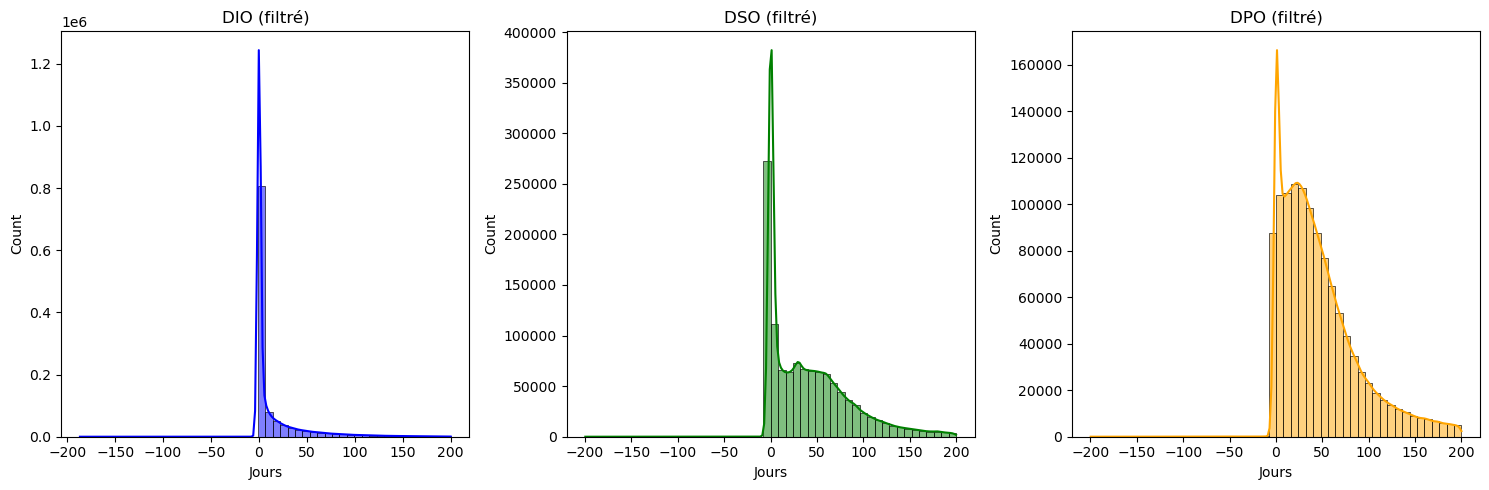

In [261]:
# Filtrage des valeurs réalistes pour chaque composante
df_filtered = df_clean[
    (df_clean["DIO"].between(-200, 200)) &
    (df_clean["DSO"].between(-200, 200)) &
    (df_clean["DPO"].between(-200, 200))
]

# Graphiques lisibles
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.histplot(df_filtered["DIO"], bins=50, kde=True, ax=axes[0], color="blue")
axes[0].set_title("DIO (filtré)")
axes[0].set_xlabel("Jours")

sns.histplot(df_filtered["DSO"], bins=50, kde=True, ax=axes[1], color="green")
axes[1].set_title("DSO (filtré)")
axes[1].set_xlabel("Jours")

sns.histplot(df_filtered["DPO"], bins=50, kde=True, ax=axes[2], color="orange")
axes[2].set_title("DPO (filtré)")
axes[2].set_xlabel("Jours")

plt.tight_layout()
plt.show()


# Merge avec les code naf pour la deuxième partie d'analyse 

In [262]:
df_naf= pd.read_parquet(r"C:\Users\yacin\Desktop\Analyse financière entreprises\naf_final.parquet")

In [263]:
df_naf.head(20)

,siren,activitePrincipaleEtablissement,naf_clean,naf_division,naf_section,secteur_macro
0,000325175,32.12Z,32.12Z,32,C,Industrie manufacturière
1,001807254,95.24Z,95.24Z,95,S,Autres services
2,005410220,22.02,22.02,22,C,Industrie manufacturière
3,005410345,79.06,79.06,79,N,Services administratifs
4,005410394,64.42,64.42,64,K,Finance / Assurance
5,005410428,70.2C,70.2C,70,M,Services spécialisés
6,005410436,57.11,57.11,57,None,Secteur inconnu
7,005410485,64.42,64.42,64,K,Finance / Assurance
8,005410493,86.06,86.06,86,Q,Santé
9,005410501,55.4B,55.4B,55,I,Hébergement / Restauration


In [264]:
df_clean.loc[:, "siren"] = df_clean["siren"].astype(str)

df_naf["siren"] = df_naf["siren"].astype(str)


C:\Users\yacin\AppData\Local\Temp\ipykernel_16260\2009467438.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['493287213' '493287338' '493288617' ... '751483223' '505369595'
 '751483223']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_clean.loc[:, "siren"] = df_clean["siren"].astype(str)


In [265]:
df_final = df_clean.merge(
    df_naf[["siren", "naf_clean", "naf_division", "naf_section", "secteur_macro"]],
    on="siren",
    how="left"
)


In [266]:
df_final.columns

Index(['siren', 'date_cloture_exercice', 'Chiffre_d_affaires', 'Marge_brute',
       'EBE', 'EBIT', 'Resultat_net', 'Taux_d_endettement',
       'Ratio_de_liquidite', 'Ratio_de_vetuste', 'Autonomie_financiere',
       'Poids_BFR_exploitation_sur_CA', 'Couverture_des_interets',
       'CAF_sur_CA', 'Capacite_de_remboursement', 'Marge_EBE',
       'Resultat_courant_avant_impots_sur_CA',
       'Poids_BFR_exploitation_sur_CA_jours', 'Rotation_des_stocks_jours',
       'Credit_clients_Jours', 'Credit_fournisseurs_Jours', 'type_bilan',
       'confidentiality', 'annee', 'DIO', 'DSO', 'DPO', 'Cycle_exploitation',
       'naf_clean', 'naf_division', 'naf_section', 'secteur_macro'],
      dtype='object')

In [267]:
df_final.head(20)

,siren,date_cloture_exercice,Chiffre_d_affaires,Marge_brute,EBE,EBIT,Resultat_net,Taux_d_endettement,Ratio_de_liquidite,Ratio_de_vetuste,...,confidentiality,annee,DIO,DSO,DPO,Cycle_exploitation,naf_clean,naf_division,naf_section,secteur_macro
0,493287213,2016-08-31,2078915.0,316815.0,44407.0,36895.0,35656.0,0.146,160.886,3.615,...,Public,2016,11.036,33.982,58.937,-13.919,46.73A,46,G,Commerce
1,493287338,2020-12-31,63890.0,63890.0,-13232.0,-10542.0,-10542.0,3.915,466.802,0.000,...,Public,2020,0.000,87.051,24.323,62.728,49.41A,49,H,Transport
2,493288617,2023-08-31,0.0,0.0,-25891.0,-26385.0,34705.0,0.072,11372.507,0.258,...,Public,2023,NaN,NaN,115.666,NaN,64.20Z,64,K,Finance / Assurance
3,493288682,2023-12-31,25341.0,25341.0,4777.0,3104.0,3273.0,0.000,191.391,32.941,...,Public,2023,0.000,0.000,26.055,-26.055,70.22Z,70,M,Services spécialisés
4,493290043,2015-12-31,85578.0,85578.0,4104.0,824.0,25.0,4.499,228.417,15.255,...,Public,2015,0.000,96.456,7.963,88.493,60.2M,60,J,Information / Communication
5,493290597,2020-12-31,0.0,0.0,-25424.0,-309751.0,-254213.0,-5.073,75.651,NaN,...,Public,2020,NaN,NaN,13002.612,NaN,64.20Z,64,K,Finance / Assurance
6,493292437,2017-12-31,0.0,0.0,-7048.0,-7114.0,193892.0,0.009,215.313,0.000,...,Public,2017,NaN,NaN,0.000,NaN,69.20Z,69,M,Services spécialisés
7,493293179,2023-12-31,0.0,0.0,-22202.0,-76178.0,-310697.0,0.000,1006.559,0.521,...,Public,2023,NaN,NaN,7.145,NaN,56.10A,56,I,Hébergement / Restauration
8,493297584,2019-12-31,11923566.0,11902561.0,-51077.0,-117234.0,-116317.0,0.000,99.269,15.138,...,Public,2019,3.171,95.299,152.300,-53.830,38.21Z,38,E,Eau / Déchets
9,493301543,2022-12-31,101122.0,75686.0,5515.0,8193.0,6823.0,2.152,622.501,0.000,...,Public,2022,0.000,83.798,50.302,33.496,70.22Z,70,M,Services spécialisés


In [268]:
df_final.isna().sum()

siren                                        0
date_cloture_exercice                        0
Chiffre_d_affaires                           0
Marge_brute                                  0
EBE                                          0
EBIT                                         0
Resultat_net                                 0
Taux_d_endettement                           0
Ratio_de_liquidite                       51121
Ratio_de_vetuste                        527000
Autonomie_financiere                       778
Poids_BFR_exploitation_sur_CA           684276
Couverture_des_interets                 392396
CAF_sur_CA                              682477
Capacite_de_remboursement               389859
Marge_EBE                               681545
Resultat_courant_avant_impots_sur_CA    681545
Poids_BFR_exploitation_sur_CA_jours     684276
Rotation_des_stocks_jours               684276
Credit_clients_Jours                    644667
Credit_fournisseurs_Jours               361067
type_bilan   

In [269]:
df_final["secteur_macro"].value_counts(dropna=False)


secteur_macro
Services spécialisés           441829
Commerce                       318692
Finance / Assurance            277078
Construction                   210408
Transport                      128855
Industrie manufacturière       126824
Services administratifs         96872
Information / Communication     96422
Immobilier                      79673
Hébergement / Restauration      75327
Autres services                 33170
Santé                           26979
Éducation                       25227
Arts / Spectacles               22715
Énergie                         14748
Secteur inconnu                 14488
Agriculture                     11170
Eau / Déchets                    8752
NaN                              6614
Industries extractives           2667
Administration publique            74
Name: count, dtype: int64

In [270]:

# Calcul du % de valeurs manquantes par colonne
missing_percent = df_final.isnull().mean() * 100


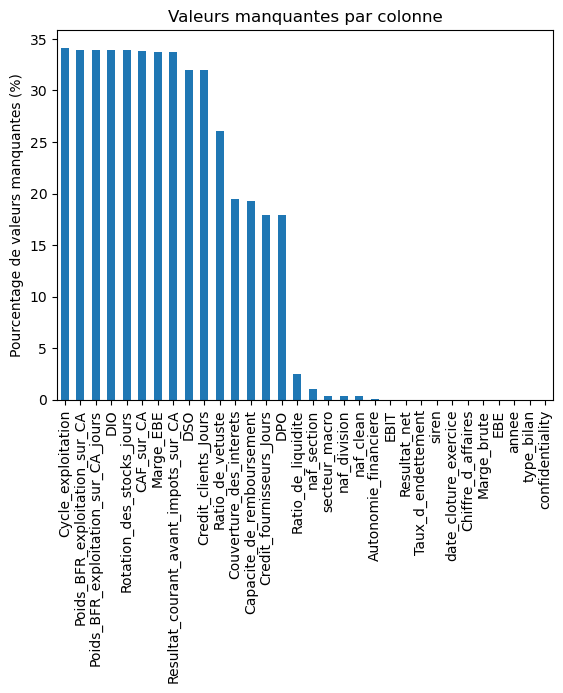

In [271]:
missing_percent.sort_values(ascending=False).plot(kind='bar')

plt.ylabel("Pourcentage de valeurs manquantes (%)")
plt.title("Valeurs manquantes par colonne")
plt.show()

#### On prépare les sous‑ensembles d’analyse

 1 -  Pour le BFR par secteur

In [272]:
df_bfr = df_final.dropna(subset=["Poids_BFR_exploitation_sur_CA"])


KeyboardInterrupt: 

2 - Pour le cycle d’exploitation

In [ ]:
df_cycle = df_final.dropna(subset=["Cycle_exploitation"])


3- Pour DIO / DSO / DPO

In [ ]:
df_flux = df_final.dropna(subset=["DIO", "DSO", "DPO"])


### 3) Analyse sectorielle — Étape 1 : BFR par secteur

In [ ]:
#Médiane du BFR / CA par secteur
df_bfr.groupby("secteur_macro")["Poids_BFR_exploitation_sur_CA"].median().sort_values()


secteur_macro
Autres services                -5.1200
Hébergement / Restauration     -3.6500
Immobilier                      0.1200
Santé                           2.6330
Éducation                       3.2525
Arts / Spectacles               4.1550
Administration publique         5.5620
Services administratifs         6.3530
Construction                    8.2100
Information / Communication     8.2390
Services spécialisés           11.3345
Commerce                       11.4870
Énergie                        12.9190
Secteur inconnu                13.3130
Agriculture                    14.2935
Transport                      15.3800
Eau / Déchets                  19.6020
Industrie manufacturière       20.0660
Finance / Assurance            24.0330
Industries extractives         28.2525
Name: Poids_BFR_exploitation_sur_CA, dtype: float64

#### Distribution (boxplot)

<Axes: title={'center': 'Poids_BFR_exploitation_sur_CA'}, xlabel='secteur_macro'>

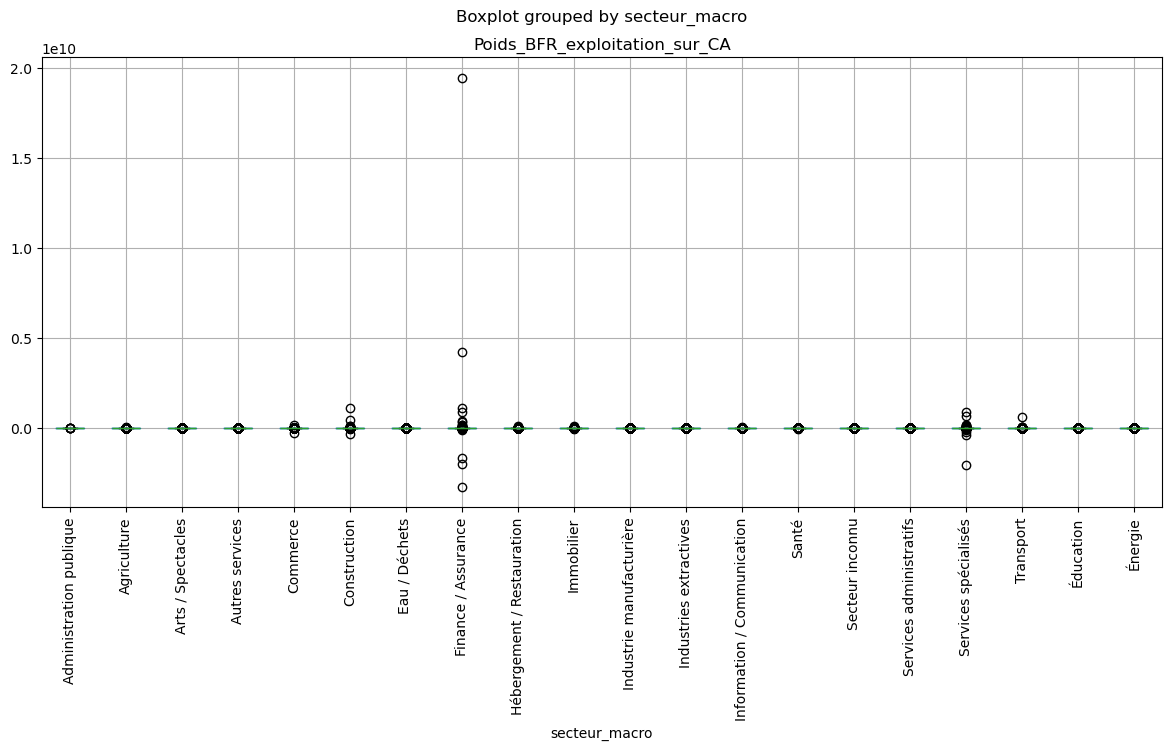

In [ ]:
# Distribution (boxplot)
df_bfr.boxplot(column="Poids_BFR_exploitation_sur_CA", by="secteur_macro", rot=90, figsize=(14,6))


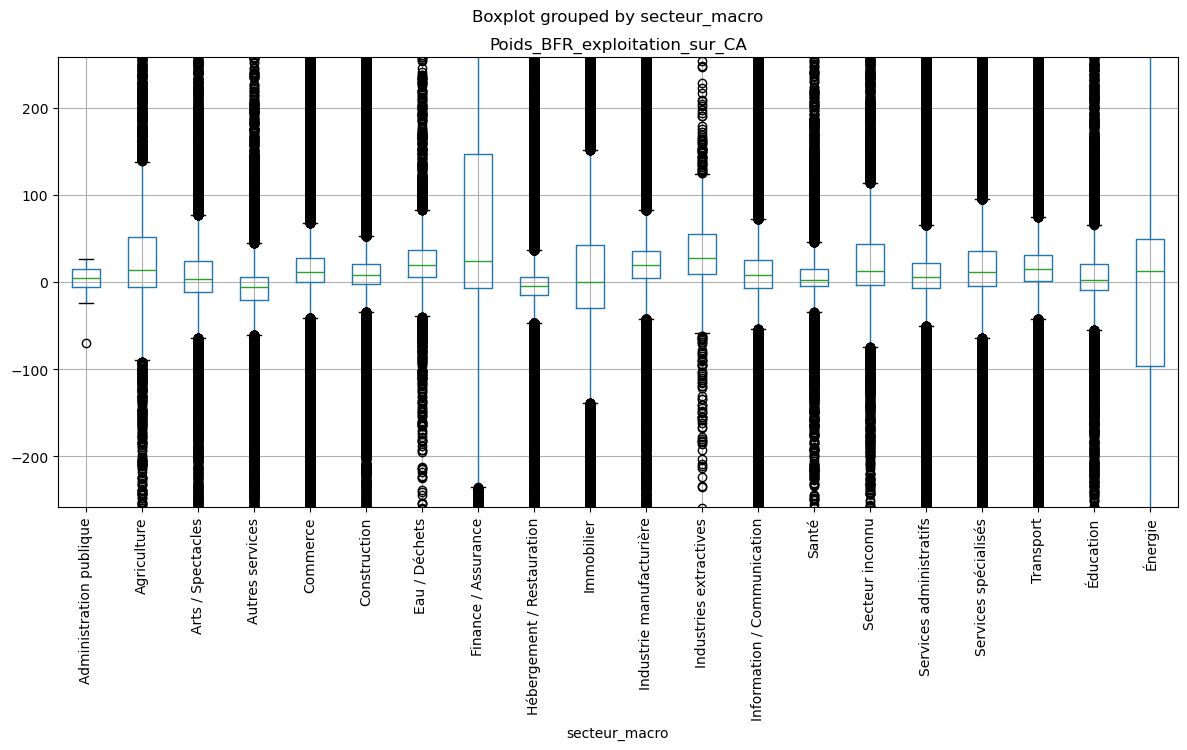

In [ ]:
limite = df_bfr["Poids_BFR_exploitation_sur_CA"].quantile(0.95)

df_bfr.boxplot(
    column="Poids_BFR_exploitation_sur_CA",
    by="secteur_macro",
    rot=90,
    figsize=(14,6)
)
plt.ylim(-limite, limite)
plt.show()


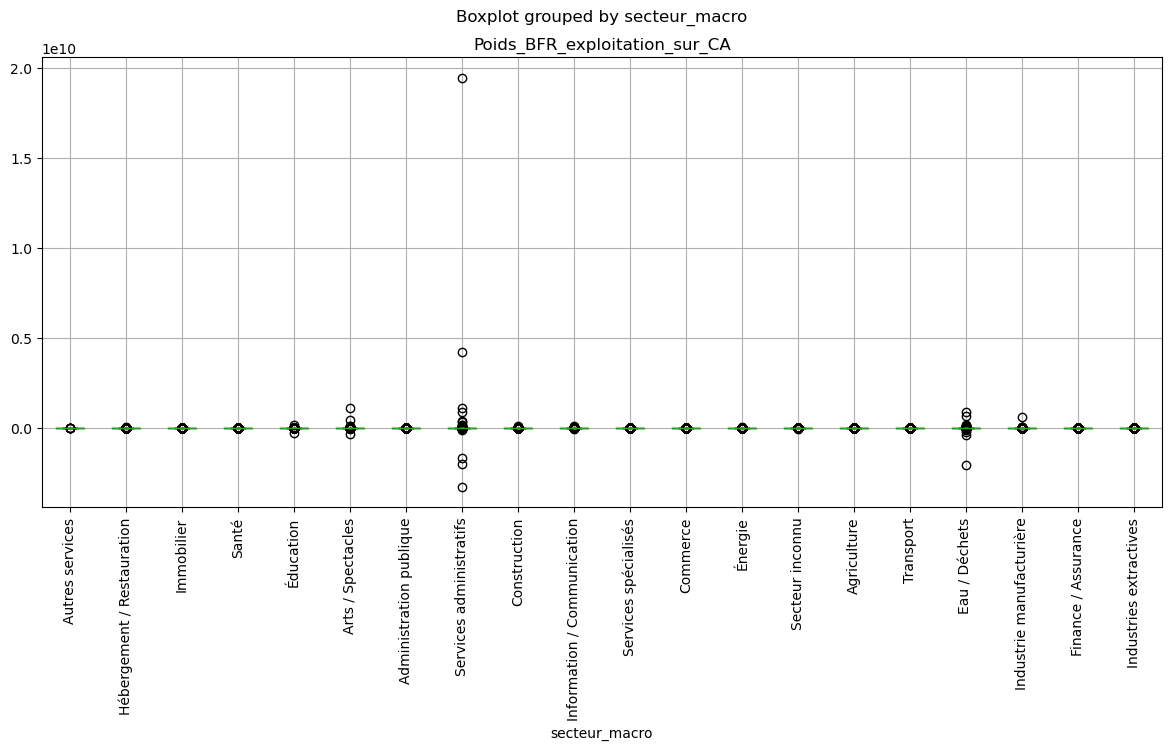

In [ ]:
# 2) Trier les secteurs par médiane 
ordre = df_bfr.groupby("secteur_macro")["Poids_BFR_exploitation_sur_CA"].median().sort_values().index

df_bfr.boxplot(
    column="Poids_BFR_exploitation_sur_CA",
    by="secteur_macro",
    rot=90,
    figsize=(14,6)
)
plt.xticks(ticks=range(1, len(ordre)+1), labels=ordre)
plt.show()


C:\Users\yacin\AppData\Local\Temp\ipykernel_16260\1340517861.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


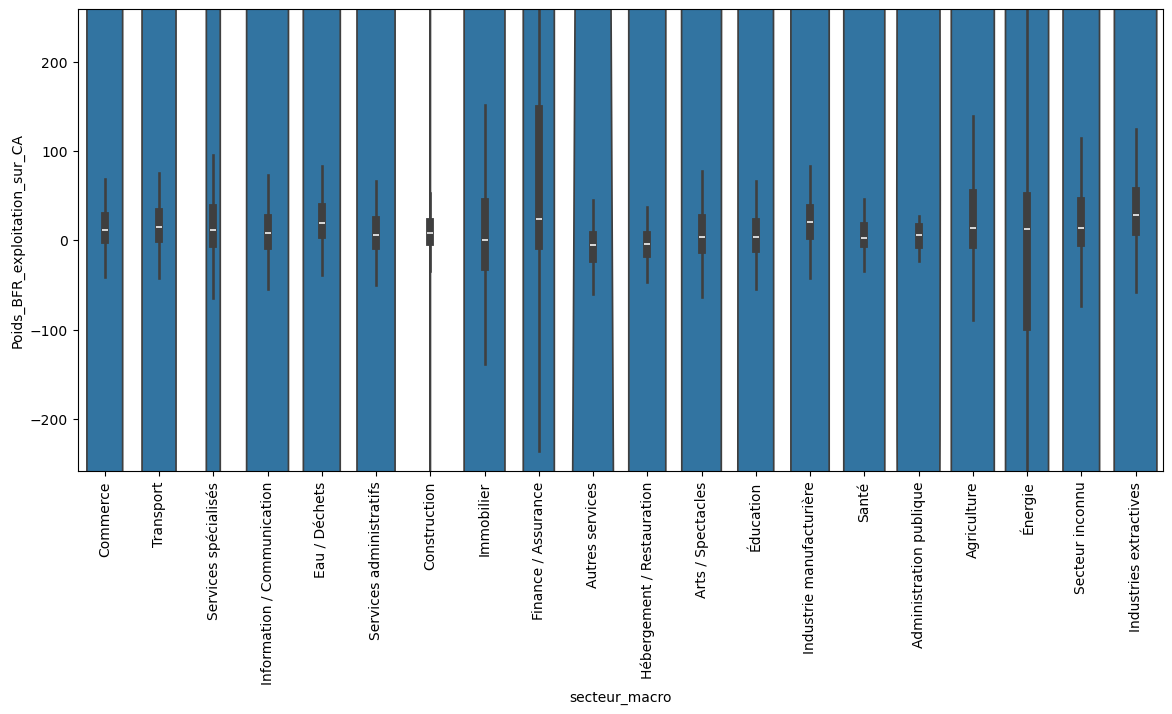

In [ ]:
# utiliser un violinplot (plus lisible que le boxplot)

plt.figure(figsize=(14,6))
sns.violinplot(
    data=df_bfr,
    x="secteur_macro",
    y="Poids_BFR_exploitation_sur_CA",
    scale="width",
    cut=0
)
plt.xticks(rotation=90)
plt.ylim(-limite, limite)
plt.show()


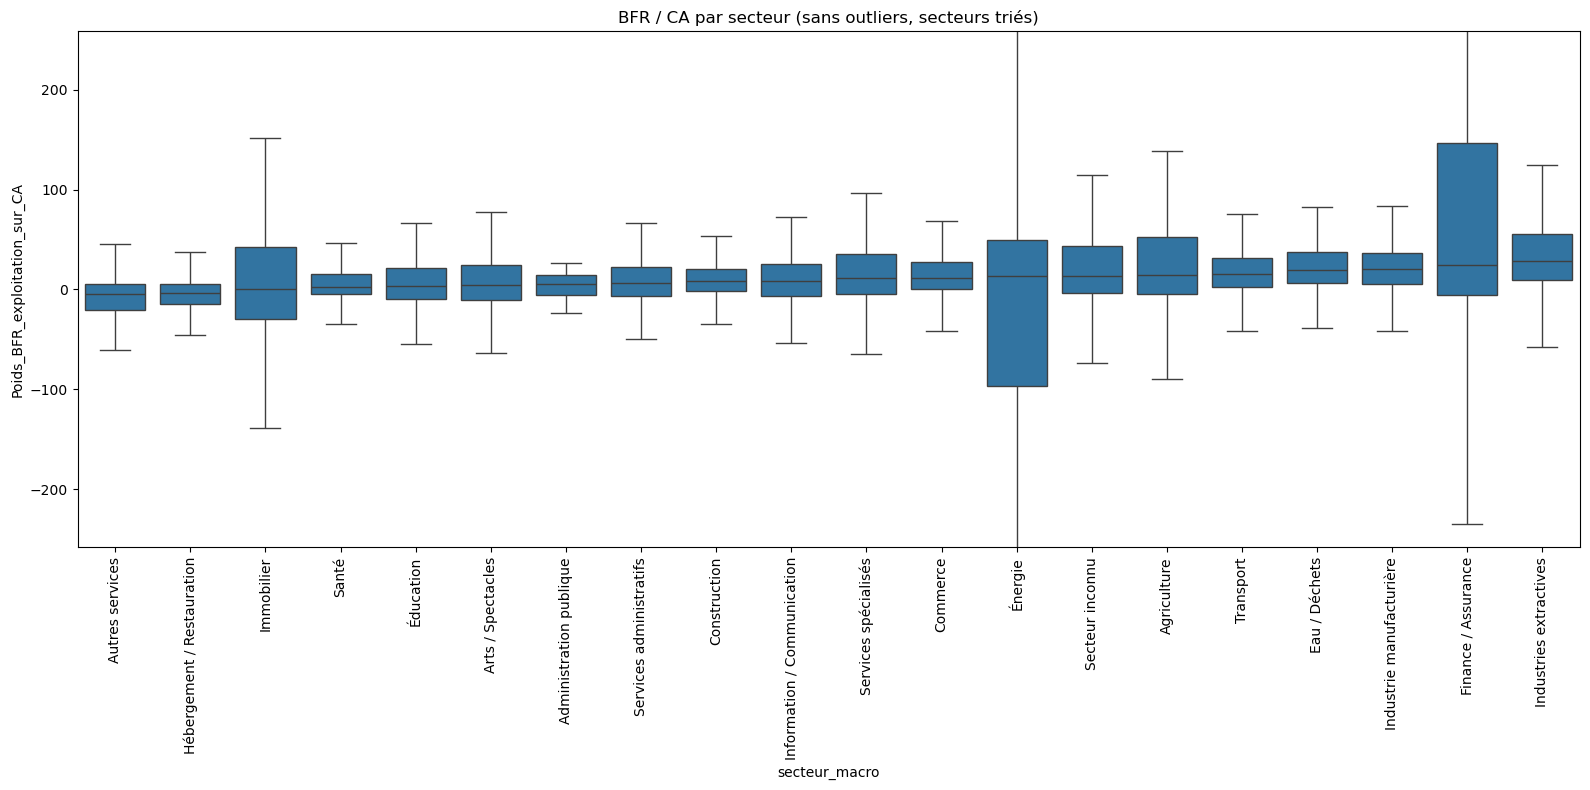

In [ ]:
# Limite pour éviter les outliers extrêmes
limite = df_bfr["Poids_BFR_exploitation_sur_CA"].quantile(0.95)

# Ordre des secteurs par médiane
ordre = df_bfr.groupby("secteur_macro")["Poids_BFR_exploitation_sur_CA"] \
              .median() \
              .sort_values() \
              .index

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df_bfr,
    x="secteur_macro",
    y="Poids_BFR_exploitation_sur_CA",
    order=ordre,
    showfliers=False  # on masque les outliers pour une meilleure lisibilité
)

plt.xticks(rotation=90)
plt.ylim(-limite, limite)
plt.title("BFR / CA par secteur (sans outliers, secteurs triés)")
plt.tight_layout()
plt.show()


In [ ]:
"""Autres services, Hébergement/Restauration, Immobilier, Santé, Éducation, Arts/Spectacles

Ces secteurs ont :

un BFR faible

une faible variabilité

un cycle d’exploitation court

peu de stocks

des encaissements rapides

Ce sont des secteurs “cash-light” : ils tournent vite, immobilisent peu de trésorerie."""

'Autres services, Hébergement/Restauration, Immobilier, Santé, Éducation, Arts/Spectacles\n\nCes secteurs ont :\n\nun BFR faible\n\nune faible variabilité\n\nun cycle d’exploitation court\n\npeu de stocks\n\ndes encaissements rapides\n\nCe sont des secteurs “cash-light” : ils tournent vite, immobilisent peu de trésorerie.'

In [ ]:
"""Services administratifs, Construction, Information/Communication, Services spécialisés, Commerce

Ce sont des secteurs :

avec un BFR plus élevé

mais relativement stable

dépendants des délais clients/fournisseurs

avec parfois un peu de stock (commerce, construction)

Ce sont des secteurs “normaux” en termes de BFR, ni trop lourds ni trop légers."""

'Services administratifs, Construction, Information/Communication, Services spécialisés, Commerce\n\nCe sont des secteurs :\n\navec un BFR plus élevé\n\nmais relativement stable\n\ndépendants des délais clients/fournisseurs\n\navec parfois un peu de stock (commerce, construction)\n\nCe sont des secteurs “normaux” en termes de BFR, ni trop lourds ni trop légers.'

In [ ]:
"""Secteurs à BFR ÉLEVÉ (forte immobilisation de trésorerie)
Énergie, Agriculture, Transport, Eau/Déchets, Industrie manufacturière

Ces secteurs ont :

des cycles longs

des stocks importants (industrie, agriculture)

des délais clients longs (transport, énergie)

des investissements lourds

Ce sont des secteurs structurellement gourmands en BFR."""

'Secteurs à BFR ÉLEVÉ (forte immobilisation de trésorerie)\nÉnergie, Agriculture, Transport, Eau/Déchets, Industrie manufacturière\n\nCes secteurs ont :\n\ndes cycles longs\n\ndes stocks importants (industrie, agriculture)\n\ndes délais clients longs (transport, énergie)\n\ndes investissements lourds\n\nCe sont des secteurs structurellement gourmands en BFR.'

In [ ]:
"""Secteurs à BFR TRÈS ÉLEVÉ et VOLATIL
Finance / Assurance, Industries extractives

Ce sont les secteurs les plus extrêmes :

très forte variabilité

valeurs extrêmes même après suppression des outliers

modèles économiques atypiques

cycles financiers complexes

immobilisations massives (extractives)

Ce sont les secteurs les plus risqués en termes de BFR."""

'Secteurs à BFR TRÈS ÉLEVÉ et VOLATIL\nFinance / Assurance, Industries extractives\n\nCe sont les secteurs les plus extrêmes :\n\ntrès forte variabilité\n\nvaleurs extrêmes même après suppression des outliers\n\nmodèles économiques atypiques\n\ncycles financiers complexes\n\nimmobilisations massives (extractives)\n\nCe sont les secteurs les plus risqués en termes de BFR.'

### 4) Analyse sectorielle — Étape 2 : Cycle d’exploitation

#### Médiane du cycle par secteur

In [ ]:
df_cycle.groupby("secteur_macro")["Cycle_exploitation"].median().sort_values()


secteur_macro
Hébergement / Restauration    -17.1380
Santé                         -11.8890
Immobilier                     -9.6550
Énergie                        -9.6285
Secteur inconnu                -8.0660
Finance / Assurance            -7.4285
Autres services                -5.9595
Arts / Spectacles              -4.2920
Éducation                       0.0000
Services administratifs         0.0000
Services spécialisés            4.7150
Information / Communication     6.4115
Transport                       9.8685
Commerce                       10.6380
Construction                   11.8505
Eau / Déchets                  13.8600
Administration publique        15.7860
Agriculture                    17.7420
Industries extractives         26.5340
Industrie manufacturière       29.3200
Name: Cycle_exploitation, dtype: float64

### 5) Analyse sectorielle — Étape 3 : DIO / DSO / DPO 

#### Médianes par secteur 

In [ ]:
df_flux.groupby("secteur_macro")[["DIO", "DSO", "DPO"]].median()


,DIO,DSO,DPO
secteur_macro,,,
Administration publique,0.0000,40.5290,34.3900
Agriculture,2.3555,38.0180,46.5215
Arts / Spectacles,0.0000,25.3730,42.2225
Autres services,1.4250,0.0000,25.5020
Commerce,14.8390,19.6930,38.8530
Construction,0.0000,39.8620,34.9645
Eau / Déchets,2.9920,60.1920,62.6670
Finance / Assurance,0.0000,34.5615,57.3995
Hébergement / Restauration,2.8180,0.0000,27.7900


### 6) Analyse sectorielle — Étape 4 : Graphiques


#### 1) Barplot — BFR médian par secteur

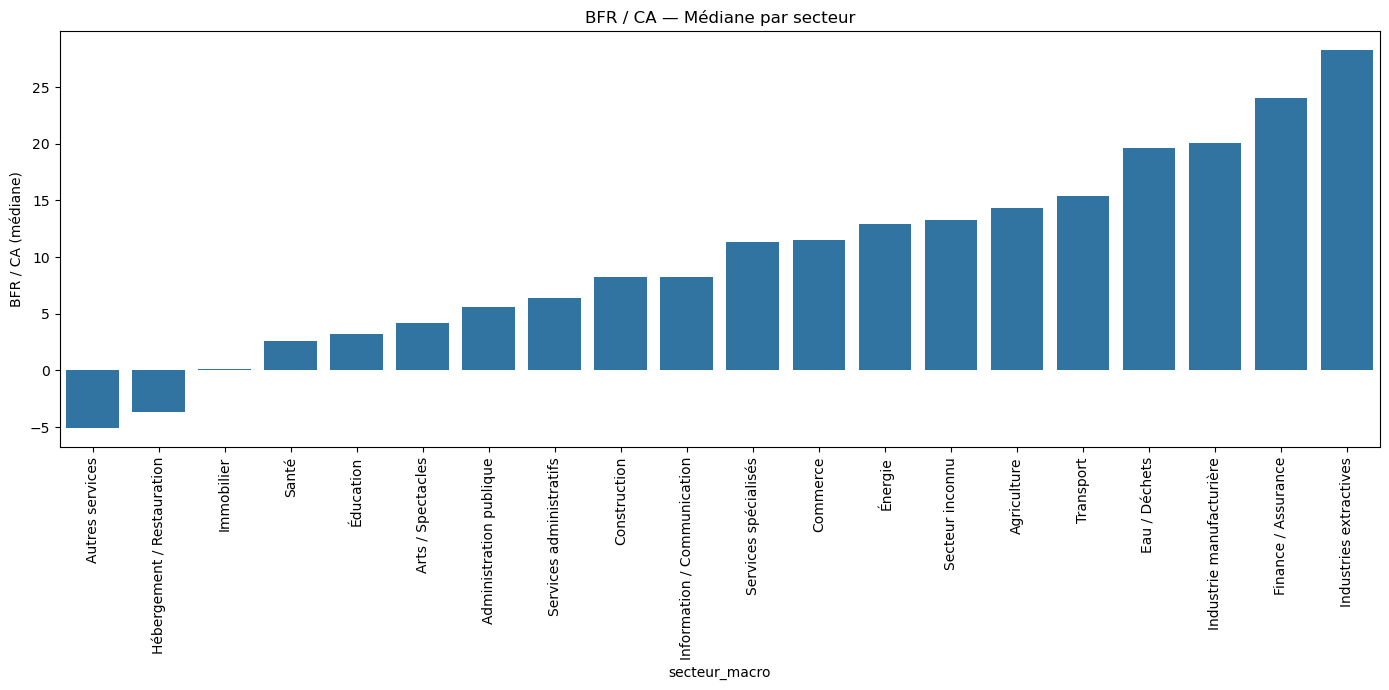

In [ ]:


bfr_median = df_bfr.groupby("secteur_macro")["Poids_BFR_exploitation_sur_CA"].median().sort_values()

plt.figure(figsize=(14, 7))
sns.barplot(x=bfr_median.index, y=bfr_median.values)
plt.xticks(rotation=90)
plt.title("BFR / CA — Médiane par secteur")
plt.ylabel("BFR / CA (médiane)")
plt.tight_layout()
plt.show()


In [276]:
""" Autres services, Hébergement/Restauration, Immobilier, Santé, Éducation  
→ BFR très faible, parfois négatif.
→ Ce sont des secteurs “cash-light” : peu de stocks, encaissements rapides.

Services spécialisés, Commerce, Construction  
→ BFR modéré.
→ Dépendance aux délais clients/fournisseurs.

Industrie, Agriculture, Transport, Eau/Déchets, Énergie  
→ BFR élevé.
→ Cycles longs, stocks importants, immobilisation forte.

Finance / Assurance & Industries extractives  
→ BFR extrêmement élevé.
→ Modèles économiques atypiques, forte volatilité.

Conclusion  
Le BFR dépend fortement du secteur.  
Les services tournent vite, l’industrie immobilise beaucoup, la finance est extrême."""

' Autres services, Hébergement/Restauration, Immobilier, Santé, Éducation  \n→ BFR très faible, parfois négatif.\n→ Ce sont des secteurs “cash-light” : peu de stocks, encaissements rapides.\n\nServices spécialisés, Commerce, Construction  \n→ BFR modéré.\n→ Dépendance aux délais clients/fournisseurs.\n\nIndustrie, Agriculture, Transport, Eau/Déchets, Énergie  \n→ BFR élevé.\n→ Cycles longs, stocks importants, immobilisation forte.\n\nFinance / Assurance & Industries extractives  \n→ BFR extrêmement élevé.\n→ Modèles économiques atypiques, forte volatilité.\n\nConclusion  \nLe BFR dépend fortement du secteur.  \nLes services tournent vite, l’industrie immobilise beaucoup, la finance est extrême.'

#### 2) Heatmap — DIO / DSO / DPO par secteur

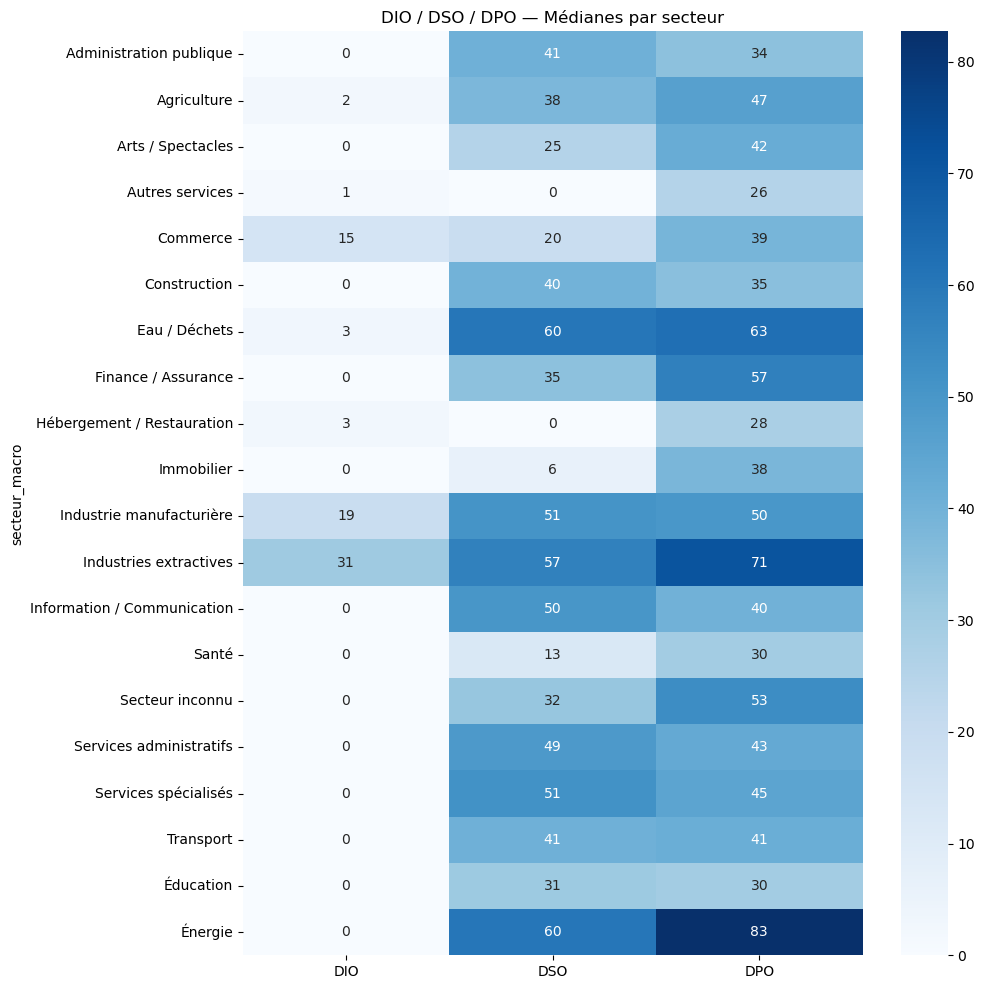

In [275]:
table = df_flux.groupby("secteur_macro")[["DIO", "DSO", "DPO"]].median()

plt.figure(figsize=(10, 12))
sns.heatmap(table, annot=True, cmap="Blues", fmt=".0f")
plt.title("DIO / DSO / DPO — Médianes par secteur")
plt.show()


In [277]:
"""Lecture simple et efficace

DIO (stocks)

Très élevé : Industrie manufacturière, Agriculture, Extractives

Faible : Services, Immobilier, Santé
→ Les secteurs industriels et agricoles stockent beaucoup.

DSO (clients)

Très élevé : Eau/Déchets, Énergie, Services spécialisés, Industrie

Faible : Hébergement/Restauration, Autres services
→ Les secteurs B2B attendent longtemps avant d’être payés.

DPO (fournisseurs)

Très élevé : Énergie, Extractives, Eau/Déchets

Modéré : Commerce, Industrie

Faible : Santé, Éducation
→ Certains secteurs financent leur cycle via les fournisseurs.

Conclusion  
Chaque secteur a un profil opérationnel unique :

Industrie = stocks + délais clients

Services = cycle court

Énergie = délais clients + délais fournisseurs

Agriculture = stocks extrêmes"""

'Lecture simple et efficace\n\nDIO (stocks)\n\nTrès élevé : Industrie manufacturière, Agriculture, Extractives\n\nFaible : Services, Immobilier, Santé\n→ Les secteurs industriels et agricoles stockent beaucoup.\n\nDSO (clients)\n\nTrès élevé : Eau/Déchets, Énergie, Services spécialisés, Industrie\n\nFaible : Hébergement/Restauration, Autres services\n→ Les secteurs B2B attendent longtemps avant d’être payés.\n\nDPO (fournisseurs)\n\nTrès élevé : Énergie, Extractives, Eau/Déchets\n\nModéré : Commerce, Industrie\n\nFaible : Santé, Éducation\n→ Certains secteurs financent leur cycle via les fournisseurs.\n\nConclusion  \nChaque secteur a un profil opérationnel unique :\n\nIndustrie = stocks + délais clients\n\nServices = cycle court\n\nÉnergie = délais clients + délais fournisseurs\n\nAgriculture = stocks extrêmes'

#### 3) Scatter — BFR vs Cycle d’exploitation

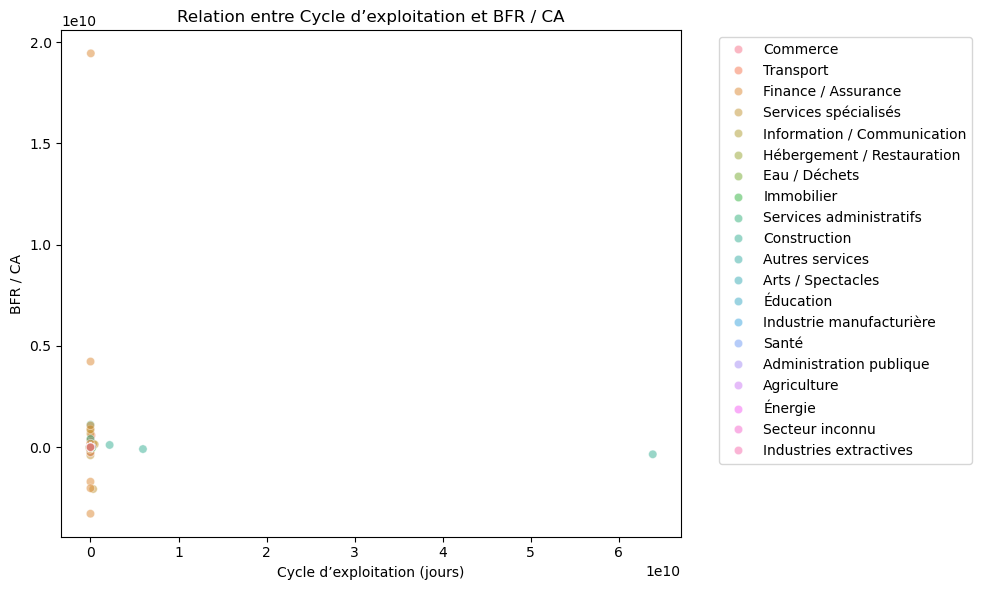

In [274]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final,
    x="Cycle_exploitation",
    y="Poids_BFR_exploitation_sur_CA",
    hue="secteur_macro",
    alpha=0.5
)
plt.title("Relation entre Cycle d’exploitation et BFR / CA")
plt.xlabel("Cycle d’exploitation (jours)")
plt.ylabel("BFR / CA")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [278]:
""" Ce que montre le scatterplot

La majorité des points sont proches de zéro → secteurs à cycle court (services).

Une diagonale apparaît : plus le cycle est long, plus le BFR augmente.

Quelques points extrêmes (Finance, Extractives) tirent le graphique.

Conclusion  
Le scatter confirme une relation logique :
Cycle long = BFR élevé.  
Les secteurs industriels et agricoles se distinguent nettement."""

' Ce que montre le scatterplot\n\nLa majorité des points sont proches de zéro → secteurs à cycle court (services).\n\nUne diagonale apparaît : plus le cycle est long, plus le BFR augmente.\n\nQuelques points extrêmes (Finance, Extractives) tirent le graphique.\n\nConclusion  \nLe scatter confirme une relation logique :\nCycle long = BFR élevé.  \nLes secteurs industriels et agricoles se distinguent nettement.'

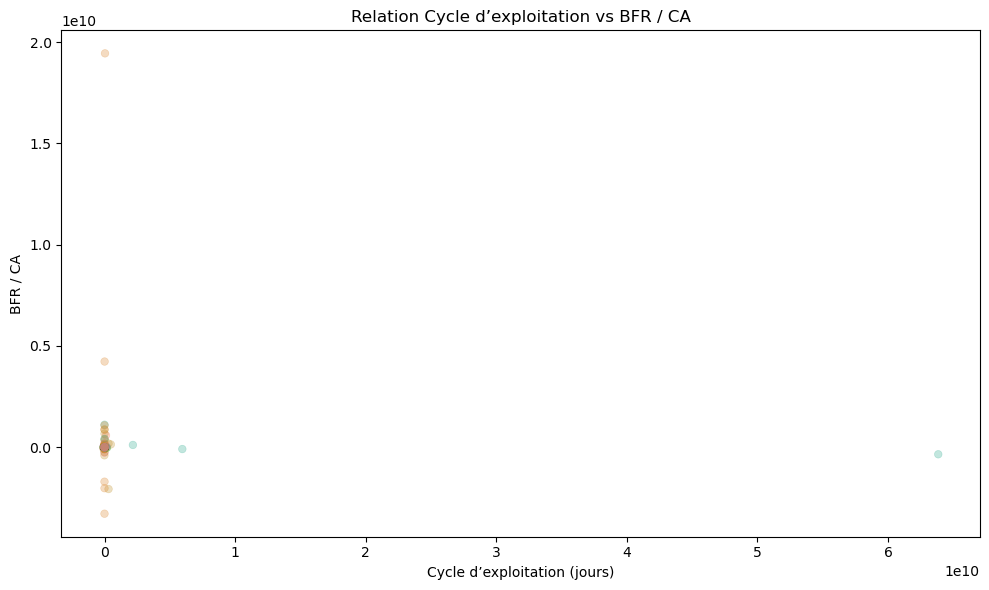

In [279]:
# Amélioration du scatterplot 
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_final,
    x="Cycle_exploitation",
    y="Poids_BFR_exploitation_sur_CA",
    hue="secteur_macro",
    alpha=0.3,
    s=30,
    edgecolor=None,
    legend=False
)
plt.title("Relation Cycle d’exploitation vs BFR / CA")
plt.xlabel("Cycle d’exploitation (jours)")
plt.ylabel("BFR / CA")
plt.tight_layout()
plt.show()


#### 4) Radar chart — Profil sectoriel

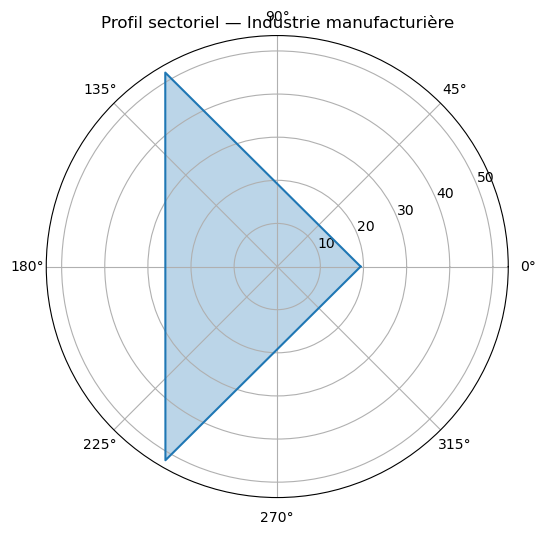

In [273]:
secteur = "Industrie manufacturière"

vals = df_final[df_final["secteur_macro"] == secteur][["DIO", "DSO", "DPO"]].median()
labels = vals.index
stats = vals.values

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
stats = np.concatenate((stats, [stats[0]]))
angles = np.concatenate((angles, [angles[0]]))

plt.figure(figsize=(6, 6))
plt.polar(angles, stats)
plt.fill(angles, stats, alpha=0.3)
plt.title(f"Profil sectoriel — {secteur}")
plt.show()


In [ ]:
"""" 1) DIO élevé — beaucoup de stocks immobilisés
L’industrie manufacturière affiche un DIO nettement supérieur aux autres secteurs.
Cela signifie :

production longue

stocks importants (matières premières + produits finis)

immobilisation de trésorerie élevée

C’est un secteur structurellement lourd en stocks.


2) DSO élevé — les clients paient lentement
Le radar montre un DSO important, ce qui indique :

des délais de paiement clients longs

une dépendance au crédit client

un risque de tension sur la trésorerie

L’industrie attend longtemps avant d’encaisser son chiffre d’affaires.


3) DPO modéré — les fournisseurs ne financent pas assez le cycle
Le DPO est :

présent

mais moins élevé que DIO et DSO

Ce qui signifie :

l’industrie paie ses fournisseurs plus vite qu’elle n’est payée

les fournisseurs ne compensent pas l’immobilisation liée aux stocks et aux clients


 Le secteur ne bénéficie pas d’un financement fournisseur suffisant.

 Conclusion sectorielle
Le radar chart montre un profil très clair :

L’industrie manufacturière est un secteur à cycle d’exploitation lourd :
beaucoup de stocks

des clients qui paient tard

des fournisseurs qui ne financent pas assez

Ce trio explique :

- un BFR élevé  
- une forte immobilisation de trésorerie  
- une sensibilité aux délais clients et aux variations de stocks""

_IncompleteInputError: incomplete input (3456090695.py, line 1)